# P1b: Counter-UAS SSG with 2D Cost Map

Scaffold notebook for Step 1: project setup, parameters, and architecture.

This notebook follows the COMPUTE / PLOT cell convention: COMPUTE cells save outputs to `data/*.json`, and PLOT cells load those files without recomputing.

In [1]:
# IMPORTS & CONFIG
import os
import json
import math

# Parameters
params = {
    # Physics / Vehicle
    'G': 9.81,
    'RHO': 1.225,
    'M': 1.5,
    'S': 0.1,
    'CD': 0.025,
    'V_STALL': 14.0,
    'V_MAX': 100.0,   # v_state_grid sampling upper bound -- covers the worst-case terminal dive speed (~98 m/s at gamma=-90, from M*G*sin(|gamma|)=0.5*RHO*v**2*CD*S); the closed-loop required_CL controller was empirically verified stable up to 110 m/s (0 failures / 3887 combos), so this is no longer an RK4-stability cap like the old open-loop CL_cmd model needed
    'T_MAX': 25.0,

    # Mission Geometry
    'Z_LAUNCH': 0.0, 'H_LAUNCH': 0.0,
    'Z_GOAL': 2500.0, 'H_GOAL': 0.0,
    'DT_GLIDE': 1.0, 'DT_POW': 1.0,
    'GAM_LAUNCH': 45.0,

    # Terrain (Gaussian)
    'Z_RIDGE': 1250.0,
    'H_RIDGE': 100.0,
    'SIGMA_TERRAIN': 200.0,

    # Sensor (default placement)
    'Z_SENSOR': 2000.0,
    'H_SENSOR': 0.0,
    'LAM_DOPPLER': 1.33e6,   # ~5 orders larger than current 4.5e2
    'LAM_RCS':     5.2e8,  # ~7 orders larger than current 6.0e3
    'SIGMA0': 1.0,
    'SIGMA_MIN': 0.1,
    'LAM_ACOUSTIC': 2.4e-3,
    'N_ACOUSTIC': 4,
    'R_FLOOR': 10.0,
    'LAM_FLOOR': 5e-4,   # noise floor on total λ. Gives baseline P_stage ≈ 0.01 at DT_DP=20s

    # Stackelberg Outer Loop
    'Z_SENSOR_MIN': 250.0,
    'Z_SENSOR_MAX': 2250.0,
    'N_SENSOR_SWEEP': 10,

    # DP Grid
    'N_Z': 200,
    'N_H': 200,
    'N_V': 1,
    'GAMMA_MIN': -90.0,
    'GAMMA_MAX': 0.0,
    'D_GAMMA': 5.0,
    'GAMMA_MIN_POINTMASS': -180.0,   # point-mass action range only -- extends GAMMA_MIN to allow backward flight (cos(gamma)<0), so an overshoot past Z_GOAL can fly back. GAMMA_MIN itself is left at -90 since lambda_rcs() uses it as a physical RCS reference angle, not an action bound.
    'DT_DP': 2.0,   # DP stage time. Must be well under the phugoid period (T = pi*sqrt(2)*v/g; ~9.5s at v=V_LAUNCH=21 m/s, longer at higher glide speeds -- empirically confirmed in Step 7) so the DP can actively damp it, not just sample an under-resolved oscillation.
    'W_TIME': 1e-3,   # time-penalty weight in J = PoD + W_TIME*T (T = elapsed travel time, seconds). Calibrated against the optimal baseline mission's elapsed time (Step 6-2: T~126s) so the time term is a real, visible fraction of a typical path's PoD -- enough to break PoD ties (e.g. PoD=0 occlusion-zone detours) and tip close calls toward the faster route, without letting time alone override an order-of-magnitude PoD difference. NOTE: this was originally cross-checked against a cumulative-PoD figure of ~1.41, which came from the (buggy) linear-sum PoD accumulation in Step 6-2 -- mathematically invalid since PoD must be <=1. Re-check this calibration against the corrected PoD once Step 6-2 is re-run.
    'H_MAX_GRID': 200.0,   # h-extent of DP grid (decoupled from terrain height)
}

# CL_MAX (stall limit) is derived, not independently chosen: V_STALL is
# defined as the speed at which CL_MAX produces exactly enough lift to hold
# level flight (L = 0.5*RHO*V_STALL**2*CL_MAX*S = M*G), so the two stay
# consistent with each other.
params['CL_MAX'] = params['M'] * params['G'] / (0.5 * params['RHO'] * params['V_STALL']**2 * params['S'])
# Powered phase flies at a constant speed, deliberately faster than stall
# (1.5x V_STALL) so it doesn't enter glide exactly at the margin -- not a
# physically simulated thrust/drag/climb, just a fixed cruise speed.
params['V_LAUNCH'] = 1.5 * params['V_STALL']
params['N_CL'] = 19   # CL action-grid resolution (matches the old gamma-action count)
params['TAU_CONTROL'] = 1.0   # autopilot attitude-tracking response time (s) -- see glider_dynamics

# Ensure data directory exists
DATA_DIR = os.path.join(os.path.dirname(__file__), 'data') if '__file__' in globals() else os.path.join(os.getcwd(), 'data')
os.makedirs(DATA_DIR, exist_ok=True)

# Save params for reproducibility
with open(os.path.join(DATA_DIR, 'params.json'), 'w') as f:
    json.dump(params, f, indent=2)

print('Parameters saved to', os.path.join(DATA_DIR, 'params.json'))

Parameters saved to D:\git\git_research\glider_hybrid_control\p1b\data\params.json


## Step Stubs

- Step 1: Project setup, parameters, architecture (this notebook)
- Step 2: Terrain + LOS computation (COMPUTE + PLOT)
- Step 3: Sensor detection model (COMPUTE + PLOT)
- Step 4: Attacker dynamics and 4D backward DP (COMPUTE + PLOT)
- Step 5: 2D projection and cost map (COMPUTE + PLOT)
- Step 6: Optimal path extraction (COMPUTE + PLOT)
- Step 7: Stackelberg outer loop (COMPUTE + PLOT)

## Step 2: Terrain + LOS Module

This section computes a Gaussian terrain profile, line-of-sight from the sensor to the terrain ridge, occlusion zones, and candidate switching points along the LOS.

In [2]:
# STEP 2 COMPUTE
import numpy as np

def h_terrain(z, params):
    """Gaussian terrain profile."""
    z_ridge = params['Z_RIDGE']
    h_ridge = params['H_RIDGE']
    sigma = params['SIGMA_TERRAIN']
    return h_ridge * np.exp(-0.5 * ((z - z_ridge) / sigma) ** 2)


def compute_LOS(z_sensor, h_sensor, params):
    """
    Compute the tangent LOS line from sensor position to the terrain curve.
    Returns slope, intercept, and tangent point on the terrain.
    """
    z_grid = np.linspace(0.0, z_sensor, 2000, endpoint=False)
    h_grid = h_terrain(z_grid, params)
    z_ridge = params['Z_RIDGE']
    sigma = params['SIGMA_TERRAIN']

    slope_line = (h_grid - h_sensor) / (z_grid - z_sensor)
    slope_terrain = h_grid * (-(z_grid - z_ridge) / sigma ** 2)
    diff = slope_line - slope_terrain

    sign_changes = np.where(np.sign(diff[:-1]) != np.sign(diff[1:]))[0]
    if sign_changes.size > 0:
        idx = sign_changes[0]
        z_tangent = float((z_grid[idx] + z_grid[idx + 1]) / 2.0)
    else:
        z_tangent = float(z_grid[np.nanargmin(np.abs(diff))])

    h_tangent = h_terrain(z_tangent, params)
    slope = (h_tangent - h_sensor) / (z_tangent - z_sensor)
    intercept = h_sensor - slope * z_sensor
    return {
        'slope': float(slope),
        'intercept': float(intercept),
        'z_tangent': z_tangent,
        'h_tangent': h_tangent,
    }


# def is_occluded(z, h, z_sensor, h_sensor, LOS, params):
#     """
#     Returns True if (z, h) is in the occlusion zone.
#     Occlusion: point is left of the tangent point and therefore blocked.
#     """
#     return float(z) < float(LOS['z_tangent'])

def is_occluded(z, h, z_sensor, h_sensor, LOS, params):
    """
    Occluded ⟺ cell is in the ridge shadow AS SEEN FROM THE SENSOR.
    Two conditions must hold simultaneously:
      (1) z < z_tangent  (cell is on the ridge-far side of the tangent point)
      (2) h < h_los(z)   (cell is below the LOS tangent line)
    If only (2) holds without (1), the cell is between the tangent point and
    the sensor — there is no terrain between them, so the cell is visible.
    """
    h_los_at_z = LOS['slope'] * z + LOS['intercept']
    return (float(z) < float(LOS['z_tangent'])) and (float(h) < float(h_los_at_z))


def compute_occlusion_mask(z_grid, h_terrain_vals, z_sensor, h_sensor, LOS, params):
    """
    Compute occlusion mask for all grid points.
    Occlusion zone: z < z_tangent (left of tangent point)
    """
    return [is_occluded(float(z), float(h), z_sensor, h_sensor, LOS, params) 
            for z, h in zip(z_grid, h_terrain_vals)]


def compute_los_mask(z_grid, h_terrain_vals, z_sensor, h_sensor, LOS, params):
    """
    Compute LOS mask for all grid points.
    LOS Zone: all region except occlusion zone and terrain.
    Equivalently: z >= z_tangent (right of tangent point)
    """
    return [not is_occluded(float(z), float(h), z_sensor, h_sensor, LOS, params) 
            for z, h in zip(z_grid, h_terrain_vals)]


def get_switching_candidates(LOS, params, n_candidates=20):
    """
    Sample candidate switching points along the LOS line,
    between z=0 and terrain peak.
    Returns list of (z_sw, h_sw).
    """
    z_peak = params['Z_RIDGE']
    z_grid = np.linspace(0.0, z_peak, n_candidates)
    return [[float(z), float(LOS['slope'] * z + LOS['intercept'])] for z in z_grid]

z_max = max(params['Z_SENSOR'], params['Z_RIDGE'])
z_grid = np.linspace(0.0, z_max, 401)
h_terrain_vals = h_terrain(z_grid, params).tolist()
LOS = compute_LOS(params['Z_SENSOR'], params['H_SENSOR'], params)
occlusion_mask = compute_occlusion_mask(z_grid, h_terrain_vals, params['Z_SENSOR'], params['H_SENSOR'], LOS, params)
los_mask = compute_los_mask(z_grid, h_terrain_vals, params['Z_SENSOR'], params['H_SENSOR'], LOS, params)
switching_candidates = get_switching_candidates(LOS, params, n_candidates=20)

terrain_data = {
    "params": params,
    "z_grid": z_grid.tolist(),
    "h_terrain": h_terrain_vals,
    "LOS": LOS,
    "occlusion_mask": occlusion_mask,
    "los_mask": los_mask,
    "switching_candidates": switching_candidates,
}

terrain_path = os.path.join(DATA_DIR, 'terrain.json')
with open(terrain_path, 'w') as f:
    json.dump(terrain_data, f, indent=2)

print('Terrain data saved to', terrain_path)

Terrain data saved to D:\git\git_research\glider_hybrid_control\p1b\data\terrain.json


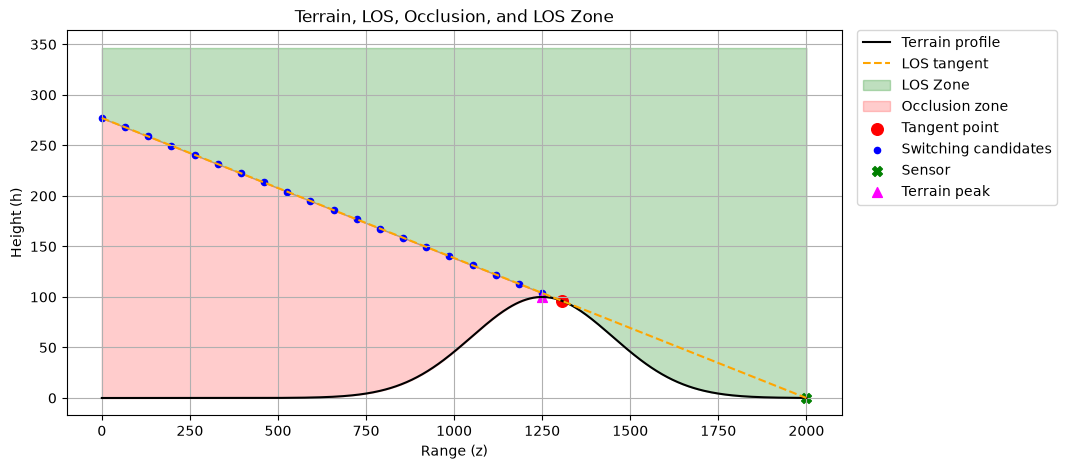

<Figure size 640x480 with 0 Axes>

In [3]:
# STEP 2 PLOT
import matplotlib.pyplot as plt
import numpy as np

terrain_path = os.path.join(DATA_DIR, 'terrain.json')
with open(terrain_path, 'r') as f:
    terrain_data = json.load(f)

z_grid = np.array(terrain_data['z_grid'])
h_terrain_vals = np.array(terrain_data['h_terrain'])
LOS = terrain_data['LOS']
occlusion_mask = np.array(terrain_data['occlusion_mask'], dtype=bool)
los_mask = np.array(terrain_data['los_mask'], dtype=bool)
switching_candidates = np.array(terrain_data['switching_candidates'])

z_sensor = terrain_data['params']['Z_SENSOR']
los_plot_mask = z_grid <= z_sensor
z_line = z_grid[los_plot_mask]
los_line = LOS['slope'] * z_line + LOS['intercept']

y_top = max(h_terrain_vals.max(), los_line.max()) * 1.25
los_line_all = LOS['slope'] * z_grid + LOS['intercept']
los_zone_boundary = np.where(z_grid <= LOS['z_tangent'], los_line_all, h_terrain_vals)

plt.figure(figsize=(10, 5))
plt.plot(z_grid, h_terrain_vals, label='Terrain profile', color='black')
plt.plot(z_line, los_line, '--', label='LOS tangent', color='orange')

# LOS Zone: visible region above LOS line left of tangent and above terrain right of tangent
plt.fill_between(z_grid, los_zone_boundary, y_top, color='green', alpha=0.25, label='LOS Zone')

# Occlusion Zone: terrain < h < LOS line, z < z_tangent
occluded_z = z_grid[occlusion_mask]
occluded_h = h_terrain_vals[occlusion_mask]
h_los_line_occluded = LOS['slope'] * occluded_z + LOS['intercept']
if occluded_z.size > 0:
    plt.fill_between(occluded_z, occluded_h, h_los_line_occluded, color='red', alpha=0.2, label='Occlusion zone')

plt.scatter([LOS['z_tangent']], [LOS['h_tangent']], c='red', s=70, marker='o', label='Tangent point')

plt.scatter(switching_candidates[:, 0], switching_candidates[:, 1], c='blue', s=20, label='Switching candidates')
plt.scatter([terrain_data['params']['Z_SENSOR']], [terrain_data['params']['H_SENSOR']], c='green', s=50, marker='X', label='Sensor')
plt.scatter([terrain_data['params']['Z_RIDGE']], [terrain_data['params']['H_RIDGE']], c='magenta', s=50, marker='^', label='Terrain peak')

plt.xlabel('Range (z)')
plt.ylabel('Height (h)')
plt.title('Terrain, LOS, Occlusion, and LOS Zone')
plt.grid(True)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.show()
plt.tight_layout()

## Step 3: Sensor Detection Module

This section implements sensor detection models for acoustic, Doppler radar, and RCS radar channels. Detection rates are computed over a (z, h) grid with representative velocity and glide angle values, accounting for occlusion.


In [4]:
# STEP 3 COMPUTE
import numpy as np

def lambda_acoustic(z, h, v, z_sensor, h_sensor, params):
    """
    Acoustic detection rate. Powered phase only.
    λ_ac = LAM_ACOUSTIC * v^N_ACOUSTIC / max(r, R_FLOOR)^2
    r = distance from (z, h) to (z_sensor, h_sensor)
    """
    r = np.sqrt((z - z_sensor)**2 + (h - h_sensor)**2)
    r_eff = np.maximum(r, params['R_FLOOR'])
    lam_ac = params['LAM_ACOUSTIC'] * (v ** params['N_ACOUSTIC']) / (r_eff ** 2)
    return float(lam_ac)


def lambda_doppler(z, h, v, gamma, z_sensor, h_sensor, params):
    """
    Doppler radar detection rate. Both phases.
    λ_dop = LAM_DOPPLER * v_r^2 / max(r, R_FLOOR)^4
    v_r = v * cos(angle between velocity vector and LOS to sensor)
    gamma: glide angle in degrees (negative downward)
    """
    # LOS vector from aircraft to sensor
    dz = z_sensor - z
    dh = h_sensor - h
    r = np.sqrt(dz**2 + dh**2)

    if r < 1e-6:
        return 0.0

    # Velocity vector: v at angle gamma
    gamma_rad = np.radians(gamma)
    v_z = v * np.cos(gamma_rad)
    v_h = v * np.sin(gamma_rad)  # positive upward

    # LOS unit vector
    los_z = dz / r
    los_h = dh / r

    # Radial velocity component
    v_r = v_z * los_z + v_h * los_h

    r_eff = np.maximum(r, params['R_FLOOR'])
    lam_dop = params['LAM_DOPPLER'] * (v_r ** 2) / (r_eff ** 4)
    return float(lam_dop)


def lambda_rcs(z, h, gamma, z_sensor, h_sensor, params):
    """
    RCS radar detection rate. Both phases.
    λ_rcs = LAM_RCS * SIGMA0 * cos^2(gamma - gamma_min) / max(r, R_FLOOR)^4
    """
    r = np.sqrt((z - z_sensor)**2 + (h - h_sensor)**2)
    r_eff = np.maximum(r, params['R_FLOOR'])

    gamma_min = params['GAMMA_MIN']
    angle_diff = gamma - gamma_min
    cos_term = np.cos(np.radians(angle_diff))

    lam_rcs = params['LAM_RCS'] * params['SIGMA0'] * (cos_term ** 2) / (r_eff ** 4)
    return float(lam_rcs)


def lambda_total_fn(z, h, v, gamma, sensor_list, phase, LOS, params):
    """
    Fused detection rate over all sensors and channels.
    phase: 'powered' or 'glide'
    sensor_list: list of (z_s, h_s) tuples
    LOS: dict with 'slope' and 'intercept' defining the LOS line through the
         sensor tangent to the terrain.
    Returns scalar λ_total (sum over sensors and available channels).

    Occlusion: cells below the LOS line are in the ridge shadow and return 0.
    Noise floor: in visible regions, λ_total is lower-bounded by LAM_FLOOR
                 to represent baseline clutter / thermal-noise detection rate.
                 Floor is applied to the total, not per sensor.
    """
    # Occlusion check based on the LOS line.
    h_los_at_z = LOS['slope'] * z + LOS['intercept']
    if (z < LOS['z_tangent']) and (h < h_los_at_z):
        return 0.0

    lam = 0.0
    for z_s, h_s in sensor_list:
        # Acoustic (powered phase only)
        if phase == 'powered':
            lam += lambda_acoustic(z, h, v, z_s, h_s, params)

        # Doppler and RCS (both phases)
        lam += lambda_doppler(z, h, v, gamma, z_s, h_s, params)
        lam += lambda_rcs(z, h, gamma, z_s, h_s, params)

    # Noise floor: applied to total λ in visible region only.
    lam_floor = float(params.get('LAM_FLOOR', 0.0))
    lam = max(lam, lam_floor)

    return float(lam)


# Evaluation on (z, h) grid
z_max = max(params['Z_SENSOR'], params['Z_RIDGE'])
z_grid = np.linspace(0.0, z_max, 50)
h_grid = np.linspace(0.0, params['H_RIDGE'] * 2.0, 50)

# Representative flight parameters
v_powered = 20.0  # m/s, powered phase
v_glide = 15.0    # m/s, glide phase
gamma_powered = -30.0  # degrees
gamma_glide = -45.0    # degrees

# Sensor list (single sensor for now, but scalable)
sensor_list = [(params['Z_SENSOR'], params['H_SENSOR'])]

# Create 2D grids for mapping
Z_grid, H_grid = np.meshgrid(z_grid, h_grid)

# Compute detection maps
lambda_acoustic_map = np.zeros_like(Z_grid)
lambda_doppler_map = np.zeros_like(Z_grid)
lambda_rcs_map = np.zeros_like(Z_grid)
lambda_total_powered_map = np.zeros_like(Z_grid)
lambda_total_glide_map = np.zeros_like(Z_grid)
occlusion_mask_2d = np.zeros_like(Z_grid, dtype=bool)

for i in range(len(h_grid)):
    for j in range(len(z_grid)):
        z, h = Z_grid[i, j], H_grid[i, j]

        # Acoustic (powered only)
        lambda_acoustic_map[i, j] = lambda_acoustic(z, h, v_powered, 
                                                     params['Z_SENSOR'], params['H_SENSOR'], params)

        # Doppler and RCS
        lambda_doppler_map[i, j] = lambda_doppler(z, h, v_powered, gamma_powered,
                                                  params['Z_SENSOR'], params['H_SENSOR'], params)
        lambda_rcs_map[i, j] = lambda_rcs(z, h, gamma_powered,
                                          params['Z_SENSOR'], params['H_SENSOR'], params)

        # Total detection rates
        lambda_total_powered_map[i, j] = lambda_total_fn(z, h, v_powered, gamma_powered, 
                                                      sensor_list, 'powered', LOS, params)
        lambda_total_glide_map[i, j] = lambda_total_fn(z, h, v_glide, gamma_glide,
                                                    sensor_list, 'glide', LOS, params)

        # Occlusion mask for 2D grid
        occlusion_mask_2d[i, j] = z < LOS['z_tangent']

sensor_data = {
    "params": params,
    "z_grid": z_grid.tolist(),
    "h_grid": h_grid.tolist(),
    "lambda_acoustic_map": lambda_acoustic_map.tolist(),
    "lambda_doppler_map": lambda_doppler_map.tolist(),
    "lambda_rcs_map": lambda_rcs_map.tolist(),
    "lambda_total_powered_map": lambda_total_powered_map.tolist(),
    "lambda_total_glide_map": lambda_total_glide_map.tolist(),
    "occlusion_mask_2d": occlusion_mask_2d.tolist(),
    "LOS": LOS,
}

sensor_path = os.path.join(DATA_DIR, 'sensors.json')
with open(sensor_path, 'w') as f:
    json.dump(sensor_data, f, indent=2)

print('Sensor data saved to', sensor_path)


Sensor data saved to D:\git\git_research\glider_hybrid_control\p1b\data\sensors.json


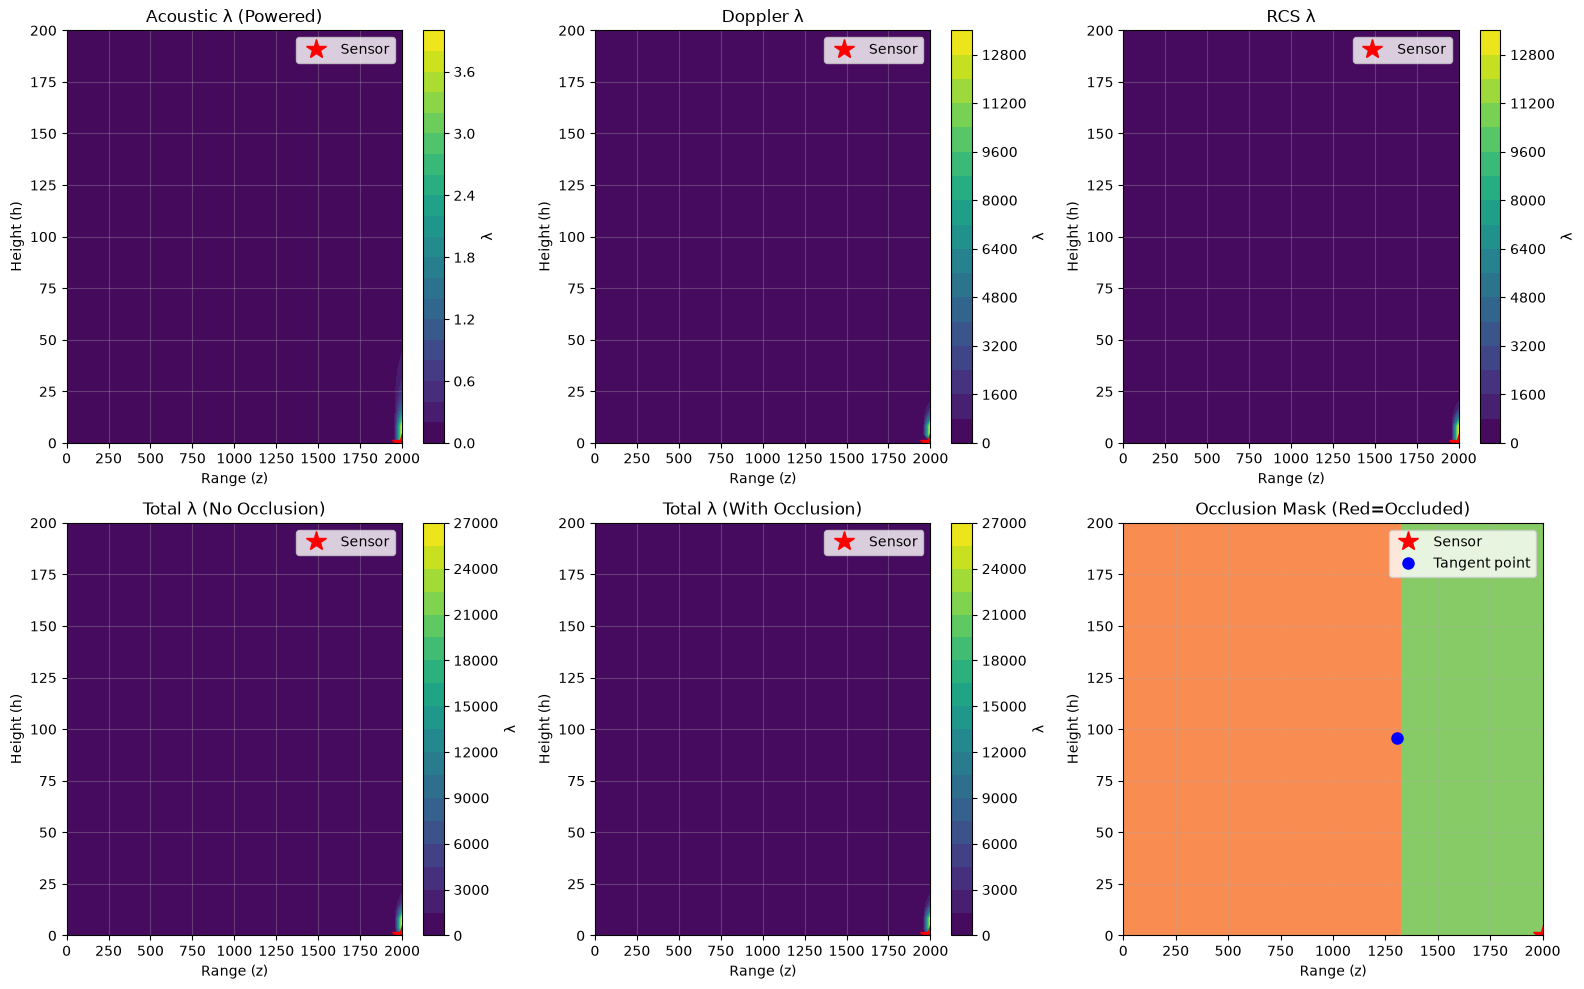

Sensor position: z=2000.0, h=0.0
Max acoustic λ: 3.8400e+00
Max doppler λ: 1.3300e+04
Max RCS λ: 1.3000e+04
Max total λ (no occlusion): 2.6304e+04
Max total λ (with occlusion): 2.6304e+04


In [5]:
# STEP 3 PLOT
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LogNorm
import numpy as np

sensor_path = os.path.join(DATA_DIR, 'sensors.json')
with open(sensor_path, 'r') as f:
    sensor_data = json.load(f)

z_grid = np.array(sensor_data['z_grid'])
h_grid = np.array(sensor_data['h_grid'])
Z_grid, H_grid = np.meshgrid(z_grid, h_grid)

# Use distinct names for arrays to avoid shadowing function names
lambda_acoustic_map = np.array(sensor_data['lambda_acoustic_map'])
lambda_doppler_map = np.array(sensor_data['lambda_doppler_map'])
lambda_rcs_map = np.array(sensor_data['lambda_rcs_map'])
lambda_total_powered_map = np.array(sensor_data['lambda_total_powered_map'])
occlusion_mask_2d = np.array(sensor_data['occlusion_mask_2d'], dtype=bool)

LOS = sensor_data['LOS']
z_sensor = sensor_data['params']['Z_SENSOR']
h_sensor = sensor_data['params']['H_SENSOR']

# Apply occlusion mask: set detection rate to 0 in occlusion zone
lambda_total_powered_occluded = lambda_total_powered_map.copy()
lambda_total_powered_occluded[occlusion_mask_2d] = 0.0

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Helper function to plot heatmap with sensor marker
def plot_detection_map(ax, data, title, z_grid, h_grid, z_sensor, h_sensor):
    im = ax.contourf(Z_grid, H_grid, data, levels=20, cmap='viridis')
    ax.plot([z_sensor], [h_sensor], 'r*', markersize=15, label='Sensor')
    ax.set_xlabel('Range (z)')
    ax.set_ylabel('Height (h)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('λ')
    return im

# Plot each detection channel
plot_detection_map(axes[0, 0], lambda_acoustic_map, 'Acoustic λ (Powered)', z_grid, h_grid, z_sensor, h_sensor)
plot_detection_map(axes[0, 1], lambda_doppler_map, 'Doppler λ', z_grid, h_grid, z_sensor, h_sensor)
plot_detection_map(axes[0, 2], lambda_rcs_map, 'RCS λ', z_grid, h_grid, z_sensor, h_sensor)

# Total detection rate before occlusion
plot_detection_map(axes[1, 0], lambda_total_powered_map, 'Total λ (No Occlusion)', z_grid, h_grid, z_sensor, h_sensor)

# Total detection rate after occlusion
plot_detection_map(axes[1, 1], lambda_total_powered_occluded, 'Total λ (With Occlusion)', z_grid, h_grid, z_sensor, h_sensor)

# Occlusion mask visualization
im_occ = axes[1, 2].contourf(Z_grid, H_grid, occlusion_mask_2d.astype(int), levels=[0, 0.5, 1], cmap='RdYlGn_r')
axes[1, 2].plot([z_sensor], [h_sensor], 'r*', markersize=15, label='Sensor')
axes[1, 2].plot([LOS['z_tangent']], [LOS['h_tangent']], 'bo', markersize=8, label='Tangent point')
axes[1, 2].set_xlabel('Range (z)')
axes[1, 2].set_ylabel('Height (h)')
axes[1, 2].set_title('Occlusion Mask (Red=Occluded)')
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].legend()

plt.tight_layout()
plt.show()

print(f"Sensor position: z={z_sensor}, h={h_sensor}")
print(f"Max acoustic λ: {lambda_acoustic_map.max():.4e}")
print(f"Max doppler λ: {lambda_doppler_map.max():.4e}")
print(f"Max RCS λ: {lambda_rcs_map.max():.4e}")
print(f"Max total λ (no occlusion): {lambda_total_powered_map.max():.4e}")
print(f"Max total λ (with occlusion): {lambda_total_powered_occluded.max():.4e}")


## Step 4: Dynamics Module

In [6]:
# STEP 4 COMPUTE
import numpy as np
import math

terrain_path = os.path.join(DATA_DIR, 'terrain.json')
with open(terrain_path, 'r') as f:
    terrain_data = json.load(f)

LOS = terrain_data['LOS']


def powered_trajectory(z_sw, h_sw, params):
    """
    Straight-line kinematics from (0, 0) to (z_sw, h_sw) at a constant
    speed V_LAUNCH (= 1.5*V_STALL, see params cell) -- no thrust/drag
    acceleration model here by design: that physics lives in the glide
    phase (glider_dynamics) only. Flying faster than exactly stall speed
    means glide entry starts with some margin rather than right at the
    edge.
    Returns list of states: [(z, h, v, gamma), ...]
    """
    v = params['V_LAUNCH']
    dt = params['DT_POW']
    distance = np.sqrt(z_sw**2 + h_sw**2)
    if distance <= 0.0:
        return [(0.0, 0.0, float(v), 0.0)]

    n_steps = max(1, int(np.ceil(distance / (v * dt))))
    z_values = np.linspace(0.0, z_sw, n_steps + 1)
    h_values = np.linspace(0.0, h_sw, n_steps + 1)
    gamma = np.arctan2(h_sw, z_sw)

    return [
        (float(z), float(h), float(v), float(gamma))
        for z, h in zip(z_values, h_values)
    ]


def drag_coefficient(CL, params):
    """
    CD(CL) -- currently a constant, independent of how much lift is being
    asked for (no induced-drag term). This is the single hook to swap in a
    full aerodynamic model: replace with a parabolic drag polar
    `params['CD0'] + params['K_INDUCED'] * CL**2` to make maneuvering near
    CL_MAX genuinely more costly, without touching glider_dynamics or any
    of the optimization pipeline that calls it.
    """
    return params['CD']


def required_CL(v, gamma, gamma_cmd, params):
    """
    Closed-loop attitude controller: the CL needed to drive gamma toward
    gamma_cmd at rate (gamma_cmd - gamma)/TAU_CONTROL (a simple
    proportional autopilot -- the closed-loop analogue of the old open-loop
    gamma lag), clipped to [0, CL_MAX]. When CL_MAX is enough to deliver
    the requested curvature, gamma tracks gamma_cmd smoothly (no
    oscillation, since the lift/weight imbalance never accumulates). When
    it isn't (the requested curvature needs more lift than available at
    this v), CL saturates at CL_MAX and gamma falls short of gamma_cmd --
    this is the stall limit, now without any wobble in the normal case.
    """
    v_safe = max(v, 1e-3)
    desired_dgamma = (gamma_cmd - gamma) / params['TAU_CONTROL']
    L_required = params['M'] * v_safe * desired_dgamma + params['M'] * params['G'] * math.cos(gamma)
    CL_required = L_required / (0.5 * params['RHO'] * v_safe**2 * params['S'])
    return float(np.clip(CL_required, 0.0, params['CL_MAX']))


def glider_dynamics_pointmass(state, gamma_cmd, params):
    """
    Point-mass BASELINE dynamics: constant speed (V_LAUNCH) and an
    instantaneous, no-inertia heading change to gamma_cmd every stage.
    Unlike the fixed-wing model below, there is no v,gamma "memory" carried
    across stages -- speed never changes and heading resets freely each
    stage -- so (z,h) alone is a sufficient (Markov) state: what you can do
    next never depends on how you got here. This is precisely why running
    Dijkstra on a pure (z,h) graph (Step 6-1/6-2) is valid for this model,
    whereas the same simplification is NOT valid for the fixed-wing model
    (there, v,gamma genuinely constrain what's reachable next -- stall,
    no-climb -- so (z,h,v,gamma) is the real Markov state).
    Returns next state after DT_GLIDE.
    """
    z, h, v, gamma = state
    v_pm = params['V_LAUNCH']
    dt = params['DT_GLIDE']
    z_next = z + v_pm * math.cos(gamma_cmd) * dt
    h_next = max(h + v_pm * math.sin(gamma_cmd) * dt, 0.0)
    return (float(z_next), float(h_next), float(v_pm), float(gamma_cmd))


def glider_dynamics(state, gamma_cmd, params):
    """
    Point-mass glide dynamics driven by a commanded target attitude
    (gamma_cmd, rad). Unlike a raw lag, the attitude tracking is mediated
    by a real closed-loop controller (required_CL above) that solves for
    the lift coefficient needed each substep and clips it at CL_MAX (the
    stall limit) -- so tracking is smooth when achievable, and physically
    limited (stall) when it isn't, instead of either an unphysical
    unlimited lag (the old gamma-lag model) or an uncontrolled open-loop CL
    command that lets gamma wobble (the CL_cmd model this replaces).

    Integration is done in Cartesian velocity components (vz, vh) rather
    than (v, gamma) directly: the polar curvature equation has a 1/v
    singularity (turn RATE blows up for a vanishing-magnitude velocity
    vector), which is numerically unstable near stall with a fixed-step
    integrator. Cartesian components have no such singularity -- at v=0,
    lift and drag (both ~v**2) vanish and the vehicle just free-falls under
    gravity, which is physically correct. state in/out is still
    (z, h, v, gamma) -- only the internal integration variable changes.
    Returns next state after DT_GLIDE. Replaceable interface -- do not
    hardcode physics elsewhere. Uses RK4 integration.
    """
    def derivatives(s):
        z, h, vz, vh = s
        v = math.hypot(vz, vh)
        v_safe = max(v, 1e-6)
        gamma = math.atan2(vh, vz)
        CL = required_CL(v, gamma, gamma_cmd, params)
        CD = drag_coefficient(CL, params)
        L = 0.5 * params['RHO'] * v**2 * CL * params['S']
        D = 0.5 * params['RHO'] * v**2 * CD * params['S']
        # forces: drag opposes velocity, lift is perpendicular (toward "up" relative to flight path)
        az = (-D * vz - L * vh) / v_safe / params['M']
        ah = (-D * vh + L * vz) / v_safe / params['M'] - params['G']
        return np.array([vz, vh, az, ah], dtype=float)

    dt = params['DT_GLIDE']
    z0, h0, v0, gamma0 = state
    s = np.array([z0, h0, v0 * math.cos(gamma0), v0 * math.sin(gamma0)], dtype=float)

    k1 = derivatives(s)
    k2 = derivatives(s + 0.5 * dt * k1)
    k3 = derivatives(s + 0.5 * dt * k2)
    k4 = derivatives(s + dt * k3)

    s_next = s + dt * (k1 + 2 * k2 + 2 * k3 + k4) / 6.0
    z_next, h_next, vz_next, vh_next = s_next
    h_next = max(h_next, 0.0)
    v_next = math.hypot(vz_next, vh_next)
    gamma_next = math.atan2(vh_next, vz_next)

    return (float(z_next), float(h_next), float(v_next), float(gamma_next))


z_goal = params['Z_GOAL']
h_goal = params['H_GOAL']

# Select switching points strictly on the LOS line and inside the occlusion zone.
z_candidates = np.linspace(0.1 * LOS['z_tangent'], 0.9 * LOS['z_tangent'], 3)

sample_trajectories = []
for idx, z_sw in enumerate(z_candidates):
    h_sw = float(LOS['slope'] * z_sw + LOS['intercept'])
    assert 0.0 < z_sw < LOS['z_tangent'], 'Switch point must remain inside occlusion zone'
    powered = powered_trajectory(z_sw, h_sw, params)

    # Illustrative only (not part of the real optimization): aim a constant
    # target attitude from the switch point toward the goal.
    gamma_cmd = float(np.arctan2(h_goal - h_sw, z_goal - z_sw))
    glide = []
    state = powered[-1]
    for _ in range(500):
        next_state = glider_dynamics(state, gamma_cmd, params)
        glide.append(next_state)
        if next_state[2] <= 0.0:
            break
        if next_state[0] >= z_goal:
            break
        state = next_state

    if len(glide) > 0 and glide[-1][0] < z_goal and glide[-1][1] > 0.0:
        glide.append((float(z_goal), 0.0, float(glide[-1][2]), float(gamma_cmd)))

    sample_trajectories.append({
        'z_sw': float(z_sw),
        'h_sw': float(h_sw),
        'powered': [[float(x) for x in s] for s in powered],
        'glide': [[float(x) for x in s] for s in glide],
    })

dynamics_data = {
    'params': params,
    'sample_trajectories': sample_trajectories,
}

with open(os.path.join(DATA_DIR, 'dynamics.json'), 'w') as f:
    json.dump(dynamics_data, f, indent=2)

print('Dynamics data saved to', os.path.join(DATA_DIR, 'dynamics.json'))

Dynamics data saved to D:\git\git_research\glider_hybrid_control\p1b\data\dynamics.json


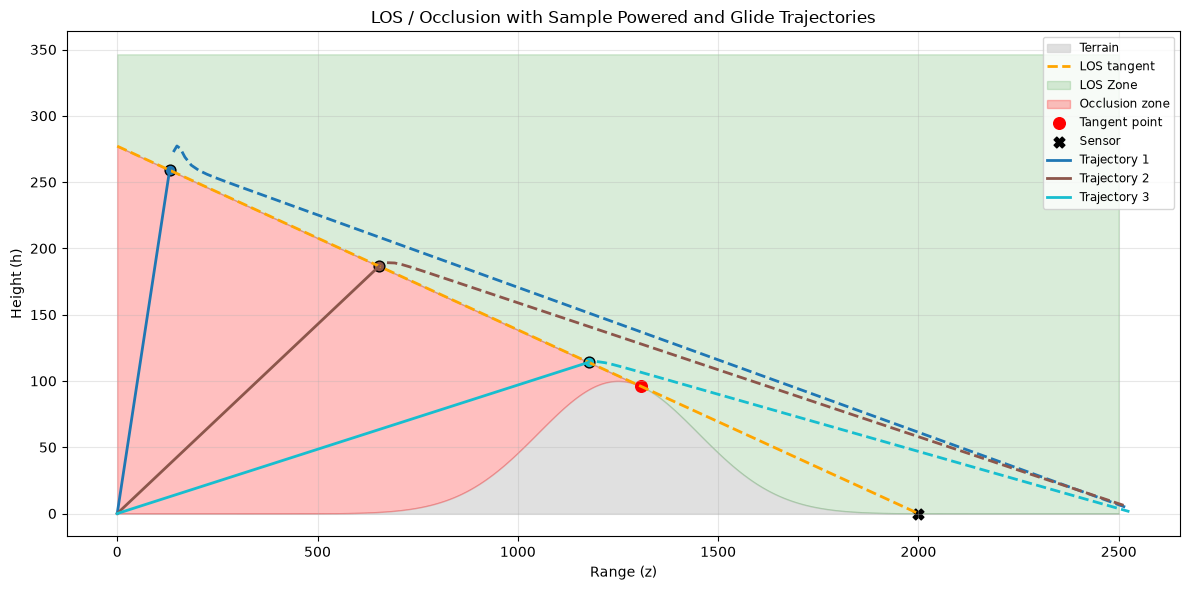

In [7]:
# STEP 4 PLOT
import matplotlib.pyplot as plt
import numpy as np

with open(os.path.join(DATA_DIR, 'terrain.json'), 'r') as f:
    terrain_data = json.load(f)
with open(os.path.join(DATA_DIR, 'dynamics.json'), 'r') as f:
    dynamics_data = json.load(f)

params_plot = terrain_data['params']
LOS = terrain_data['LOS']

# Terrain profile for background.
def h_terrain(z, params):
    z_ridge = params['Z_RIDGE']
    h_ridge = params['H_RIDGE']
    sigma = params['SIGMA_TERRAIN']
    return h_ridge * np.exp(-0.5 * ((z - z_ridge) / sigma) ** 2)

z_grid = np.array(terrain_data['z_grid'])
h_terrain_vals = np.array(terrain_data['h_terrain'])

z_plot = np.linspace(0.0, max(params_plot['Z_SENSOR'], params_plot['Z_GOAL'], params_plot['Z_RIDGE']), 601)
h_plot = h_terrain(z_plot, params_plot)
los_mask_plot = z_plot <= params_plot['Z_SENSOR']
z_line = z_plot[los_mask_plot]
los_line = LOS['slope'] * z_line + LOS['intercept']

y_top = max(h_plot.max(), np.max(los_line)) * 1.25
los_line_all = LOS['slope'] * z_plot + LOS['intercept']
los_zone_boundary = np.where(z_plot <= LOS['z_tangent'], los_line_all, h_plot)

plt.figure(figsize=(12, 6))
plt.fill_between(z_plot, 0.0, h_plot, color='lightgrey', alpha=0.7, label='Terrain')
plt.plot(z_line, los_line, '--', color='orange', linewidth=2, label='LOS tangent')
plt.fill_between(z_plot, los_zone_boundary, y_top, color='green', alpha=0.15, label='LOS Zone')

occlusion_mask = np.array(terrain_data['occlusion_mask'], dtype=bool)
occluded_z = z_grid[occlusion_mask]
occluded_h = h_terrain_vals[occlusion_mask]
h_los_line_occluded = LOS['slope'] * occluded_z + LOS['intercept']
if occluded_z.size > 0:
    plt.fill_between(occluded_z, occluded_h, h_los_line_occluded, color='red', alpha=0.25, label='Occlusion zone')

plt.scatter([LOS['z_tangent']], [LOS['h_tangent']], c='red', s=70, marker='o', label='Tangent point')
plt.scatter([params_plot['Z_SENSOR']], [params_plot['H_SENSOR']], c='black', s=60, marker='X', label='Sensor')

colors = plt.cm.tab10(np.linspace(0, 1, len(dynamics_data['sample_trajectories'])))
for idx, traj in enumerate(dynamics_data['sample_trajectories']):
    powered = np.array(traj['powered'])
    glide = np.array(traj['glide'])
    z_sw = traj['z_sw']
    h_sw = traj['h_sw']
    color = colors[idx]

    trajectory_label = f'Trajectory {idx + 1}'

    plt.plot(powered[:, 0], powered[:, 1], '-', linewidth=2, color=color, label=trajectory_label)
    if glide.size > 0:
        plt.plot(glide[:, 0], glide[:, 1], '--', linewidth=2, color=color, label='_nolegend_')
    plt.scatter([z_sw], [h_sw], s=60, c=[color], edgecolors='k', linewidths=1.0, marker='o', label='_nolegend_')

plt.xlabel('Range (z)')
plt.ylabel('Height (h)')
plt.title('LOS / Occlusion with Sample Powered and Glide Trajectories')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize='small')
plt.tight_layout()
plt.show()

## Step 5: 4D Stage Cost Table

Build the 4D instantaneous stage cost table `c_4D[iz, ih, iv, ig]` over `(z, h, v, γ)`. No optimization, no DP. Stage cost is `1 - exp(-λ_total(state) * DT_DP)` for the glide phase. Terrain validity is recorded separately as a 2D boolean mask since it does not depend on `(v, γ)`. Saved to `data/stage_cost_4d.json` and consumed by Step 6.

In [8]:
# STEP 5 COMPUTE — 4D Stage Cost Table
import numpy as np
import math

# Load dependencies from earlier steps
terrain_path = os.path.join(DATA_DIR, 'terrain.json')
with open(terrain_path, 'r') as f:
    terrain_data = json.load(f)
LOS = terrain_data['LOS']

sensor_list = [(params['Z_SENSOR'], params['H_SENSOR'])]


def build_state_grid(params):
    """
    Build 4D grid over (z, h, v, gamma).
    Returns 1D arrays. Scalable: increase N_V later to make v an action.
    """
    N_Z = int(params['N_Z'])
    N_H = int(params['N_H'])
    N_V = int(params['N_V'])
    gamma_min_deg = float(params['GAMMA_MIN'])
    gamma_max_deg = float(params['GAMMA_MAX'])
    d_gamma = float(params['D_GAMMA'])
    N_GAMMA = int(round((gamma_max_deg - gamma_min_deg) / d_gamma)) + 1

    z_grid = np.linspace(0.0, float(params['Z_GOAL']) * 1.1, N_Z)   # extra 10% past Z_GOAL so the goal is an interior cell, not the grid boundary
    # h_max = max(2.0 * float(params['H_RIDGE']), 50.0)
    # h_grid = np.linspace(0.0, h_max, N_H)
    h_grid = np.linspace(0.0, float(params['H_MAX_GRID']), N_H)


    if N_V == 1:
        v_grid = np.array([float(params['V_STALL'])])
    else:
        v_grid = np.linspace(float(params['V_STALL']), float(params['V_MAX']), N_V)

    gamma_grid = np.linspace(gamma_min_deg, gamma_max_deg, N_GAMMA)
    return z_grid, h_grid, v_grid, gamma_grid


def build_terrain_mask_2d(z_grid, h_grid, params):
    """
    terrain_mask[iz, ih] = True if (z, h) is below terrain surface (invalid).
    2D only — terrain validity does not depend on (v, gamma).
    Strict < so ground level (h=0 where h_terrain=0) is treated as valid.
    """
    TERRAIN_EPS = 1e-3  # numerical tolerance for ground level
    NZ, NH = len(z_grid), len(h_grid)
    mask = np.zeros((NZ, NH), dtype=bool)
    for iz, z in enumerate(z_grid):
        h_t = float(h_terrain(z, params))
        for ih, h in enumerate(h_grid):
            mask[iz, ih] = (h_t > TERRAIN_EPS) and (h < h_t)
    return mask


def build_stage_cost_4d(z_grid, h_grid, v_grid, gamma_grid, sensor_list, LOS, params):
    """
    c_4D[iz, ih, iv, ig] = 1 - exp(-lambda_total * DT_DP) for the glide phase.

    Pure evaluation of instantaneous stage cost on the 4D grid.
    No DP, no min/max. gamma stays as a free axis for Step 6 DP to optimize over.
    """
    NZ, NH = len(z_grid), len(h_grid)
    NV, NG = len(v_grid), len(gamma_grid)
    c_4D = np.zeros((NZ, NH, NV, NG), dtype=float)
    dt = float(params['DT_DP'])

    for iz in range(NZ):
        z = float(z_grid[iz])
        for ih in range(NH):
            h = float(h_grid[ih])
            for iv in range(NV):
                v = float(v_grid[iv])
                for ig in range(NG):
                    gamma_deg = float(gamma_grid[ig])
                    lam = lambda_total_fn(
                        z, h, v, gamma_deg,
                        sensor_list, 'glide', LOS, params
                    )
                    c_4D[iz, ih, iv, ig] = 1.0 - math.exp(-lam * dt)
    return c_4D


# Build everything
z_grid, h_grid, v_grid, gamma_grid = build_state_grid(params)
terrain_mask_2d = build_terrain_mask_2d(z_grid, h_grid, params)
c_4D = build_stage_cost_4d(z_grid, h_grid, v_grid, gamma_grid,
                            sensor_list, LOS, params)

print(f'Grid: NZ={len(z_grid)}, NH={len(h_grid)}, NV={len(v_grid)}, NG={len(gamma_grid)}')
print(f'c_4D shape: {c_4D.shape}')
print(f'c_4D range: [{c_4D.min():.4e}, {c_4D.max():.4e}]')
print(f'terrain-invalid cells (2D): {int(terrain_mask_2d.sum())} / {terrain_mask_2d.size}')

stage_cost_data = {
    'params': params,
    'z_grid': z_grid.tolist(),
    'h_grid': h_grid.tolist(),
    'v_grid': v_grid.tolist(),
    'gamma_grid': gamma_grid.tolist(),
    'c_4D': c_4D.tolist(),
    'terrain_mask_2d': terrain_mask_2d.tolist(),
}

stage_cost_path = os.path.join(DATA_DIR, 'stage_cost_4d.json')
with open(stage_cost_path, 'w') as f:
    json.dump(stage_cost_data, f, indent=2)
print('Stage cost table saved to', stage_cost_path)

Grid: NZ=200, NH=200, NV=1, NG=19
c_4D shape: (200, 200, 1, 19)
c_4D range: [0.0000e+00, 1.0000e+00]
terrain-invalid cells (2D): 3692 / 40000


Stage cost table saved to D:\git\git_research\glider_hybrid_control\p1b\data\stage_cost_4d.json


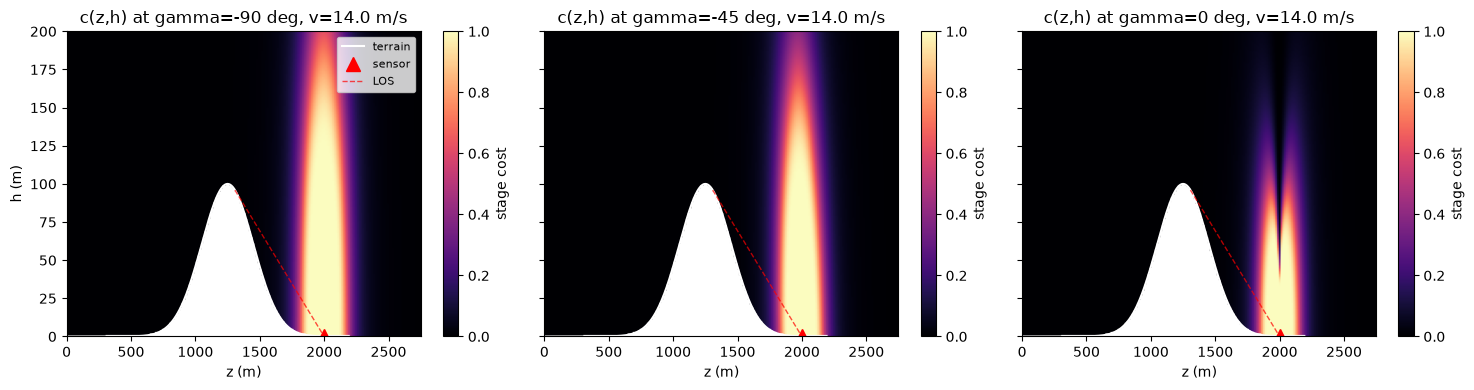

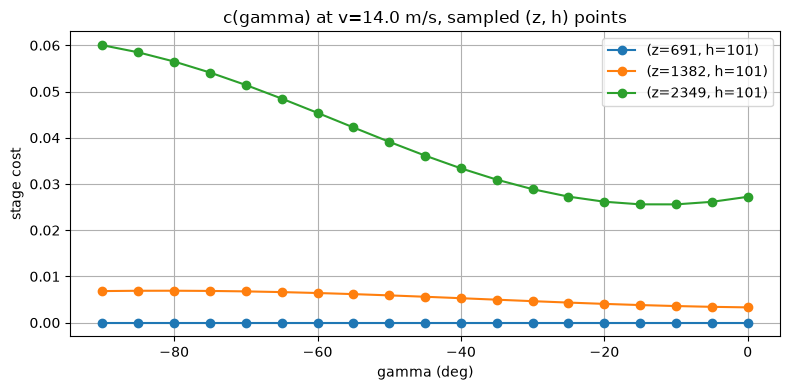

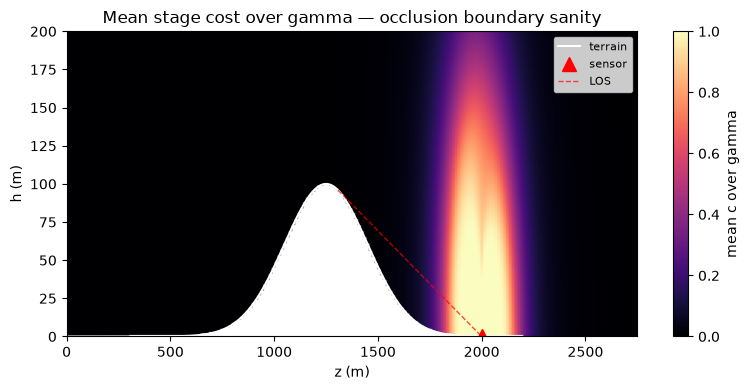

In [9]:
# STEP 5 PLOT — Stage Cost Table Visualization (load stage_cost_4d.json, no recompute)
import matplotlib.pyplot as plt
import numpy as np

stage_cost_path = os.path.join(DATA_DIR, 'stage_cost_4d.json')
with open(stage_cost_path, 'r') as f:
    sc = json.load(f)

z_grid = np.array(sc['z_grid'])
h_grid = np.array(sc['h_grid'])
v_grid = np.array(sc['v_grid'])
gamma_grid = np.array(sc['gamma_grid'])
c_4D = np.array(sc['c_4D'])
terrain_mask_2d = np.array(sc['terrain_mask_2d'])

terrain_path = os.path.join(DATA_DIR, 'terrain.json')
with open(terrain_path, 'r') as f:
    terrain_data = json.load(f)
z_terrain = np.array(terrain_data['z_grid'])
h_terrain_vals = np.array(terrain_data['h_terrain'])
LOS = terrain_data['LOS']


def mask_terrain(c_2d):
    out = c_2d.copy()
    out[terrain_mask_2d] = np.nan
    return out


def overlay(ax):
    ax.plot(z_terrain, h_terrain_vals, 'w-', lw=1.5, label='terrain')
    ax.plot(params['Z_SENSOR'], params['H_SENSOR'], 'r^',
            markersize=10, label='sensor')
    z_los = np.linspace(LOS['z_tangent'], params['Z_SENSOR'], 50)
    h_los = LOS['slope'] * z_los + LOS['intercept']
    ax.plot(z_los, h_los, 'r--', lw=1, alpha=0.7, label='LOS')


# --- Plot 1: c(z, h) heatmap at gamma slices, v fixed ---
iv = 0
gamma_slice_indices = [0, len(gamma_grid)//2, len(gamma_grid)-1]

fig, axes = plt.subplots(1, len(gamma_slice_indices), figsize=(15, 4), sharey=True)
for ax, ig in zip(axes, gamma_slice_indices):
    c_zh_masked = mask_terrain(c_4D[:, :, iv, ig])
    im = ax.imshow(
        c_zh_masked.T, origin='lower',
        extent=(z_grid[0], z_grid[-1], h_grid[0], h_grid[-1]),
        aspect='auto', cmap='magma',
    )
    overlay(ax)
    ax.set_xlabel('z (m)')
    ax.set_title(f'c(z,h) at gamma={gamma_grid[ig]:.0f} deg, v={v_grid[iv]:.1f} m/s')
    fig.colorbar(im, ax=ax, label='stage cost')
axes[0].set_ylabel('h (m)')
axes[0].legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

# --- Plot 2: c(gamma) curves at representative (z, h) points ---
sample_points_idx = [
    (len(z_grid)//4,        len(h_grid)//2),   # left, occluded
    (len(z_grid)//2,        len(h_grid)//2),   # mid
    (int(0.85*len(z_grid)), len(h_grid)//2),   # near goal, exposed
]

plt.figure(figsize=(8, 4))
for iz, ih in sample_points_idx:
    plt.plot(gamma_grid, c_4D[iz, ih, 0, :], marker='o',
             label=f'(z={z_grid[iz]:.0f}, h={h_grid[ih]:.0f})')
plt.xlabel('gamma (deg)')
plt.ylabel('stage cost')
plt.title(f'c(gamma) at v={v_grid[0]:.1f} m/s, sampled (z, h) points')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 3: occlusion boundary sanity ---
c_mean_over_gamma = c_4D[:, :, 0, :].mean(axis=-1)
c_mean_masked = mask_terrain(c_mean_over_gamma)

plt.figure(figsize=(8, 4))
im = plt.imshow(
    c_mean_masked.T, origin='lower',
    extent=(z_grid[0], z_grid[-1], h_grid[0], h_grid[-1]),
    aspect='auto', cmap='magma',
)
plt.colorbar(im, label='mean c over gamma')
overlay(plt.gca())
plt.xlabel('z (m)')
plt.ylabel('h (m)')
plt.title('Mean stage cost over gamma — occlusion boundary sanity')
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

In [10]:
# 적용 후 검증용 한 줄
print(f'min in visible region: {c_4D[c_4D > 0].min():.4f}')   # ≈ 0.01 (floor)
print(f'max: {c_4D.max():.4f}')                                # ≈ 1.0 (saturated)

min in visible region: 0.0010
max: 1.0000


## Step 6: Cost-to-Go Map + Optimal Path Extraction (point-mass baseline)

Step 6-1 builds the cost-to-go map over `(z, h)`. This is the **point-mass
baseline**: `glider_dynamics_pointmass` flies at a constant speed
(`V_LAUNCH`) and resets heading instantly (no inertia) to whatever
`gamma_cmd` is commanded each stage. Because there is no `v, gamma` memory
carried between stages, `(z, h)` alone is a sufficient (Markov) state --
what the vehicle can do next never depends on how it got to a cell, only on
where it is. This is exactly the condition required for a pure `(z,h)`
Dijkstra to be valid (see discussion above): for a fixed-wing model with
stall/no-climb constraints, `v, gamma` would carry real physical state and
`(z,h)` alone would NOT be Markov -- that richer model needs
`(z,h,v,gamma)` as DP state and is addressed in a separate section.

The edge weight for action `ig_a` out of `(z,h)` is the integrated
detection cost of flying that heading for one stage, with every substep
(not just the stage endpoints) checked against the terrain surface and
`h=0`. Real `z` overshooting past `Z_GOAL` is only accepted if it lands
close to `H_GOAL` -- otherwise rejected, so the optimizer must genuinely
finish its descent by `z=Z_GOAL` rather than being credited for free once
it crosses the boundary. Dijkstra propagates from the single goal cell
`(Z_GOAL, H_GOAL)`.

Step 6-2 executes this cost-to-go map closed-loop (receding-horizon): at
every stage, the real `(z,h)` is used to re-query the best heading via real
point-mass kinematics. Since `(z,h)` is genuinely Markov here, this is not
just convenient but exact -- there is no risk of the policy promising
something the real trajectory can't deliver (unlike the fixed-wing case).

**Objective update**: `J` now combines detection risk and travel time,
`J = PoD + W_TIME * T` (`T` = elapsed travel time in seconds, accumulated as
`DT_DP` per stage). Pure-PoD `J` had many exact ties (e.g. `PoD=0` for any
path that stays fully inside the occlusion zone), which left Dijkstra free
to pick an arbitrarily slow zero-risk path; the time term breaks those ties
in favor of the faster route without overriding a genuine PoD trade-off
(`W_TIME=1e-3` is calibrated so the full-mission time penalty is a real,
visible fraction (~10%) of a typical path's cumulative PoD -- enough to
break ties without overriding a genuine order-of-magnitude PoD
difference; see the `W_TIME` comment in the params cell, and Step 6-1b
below for a direct measurement of how many cells this actually moves).


In [11]:
# STEP 6-1 COMPUTE — 2D Cost-to-Go Map J(z,h), point-mass BASELINE
#
# (z,h) is the FULL state for this model: glider_dynamics_pointmass has
# constant speed and no-inertia heading reset every stage, so (z,h) alone is
# Markov -- what you can do next never depends on how you got here. This is
# why a pure (z,h) Dijkstra is mathematically valid here (it would NOT be
# valid for the fixed-wing model, where v,gamma genuinely constrain future
# reachability -- that model needs (z,h,v,gamma) as DP state and is left for
# a separate section below).
#
# Objective: J = PoD + W_TIME*T (not PoD alone). The edge weight below adds
# a fixed W_TIME*DT_DP time penalty per stage on top of the per-stage
# detection probability c_lagged, so Dijkstra minimizes a weighted sum of
# cumulative detection probability and elapsed travel time.
import heapq
import math
import numpy as np

stage_cost_path = os.path.join(DATA_DIR, 'stage_cost_4d.json')
with open(stage_cost_path, 'r') as f:
    sc = json.load(f)

terrain_path = os.path.join(DATA_DIR, 'terrain.json')
with open(terrain_path, 'r') as f:
    terrain_data = json.load(f)
LOS = terrain_data['LOS']
sensor_list = [(params['Z_SENSOR'], params['H_SENSOR'])]

z_grid = np.array(sc['z_grid'])
h_grid = np.array(sc['h_grid'])
c_4D = np.array(sc['c_4D'])
terrain_mask_2d = np.array(sc['terrain_mask_2d'], dtype=bool)
NZ, NH = len(z_grid), len(h_grid)
z_step = float(z_grid[1] - z_grid[0])

NG = int(round((params['GAMMA_MAX'] - params['GAMMA_MIN_POINTMASS']) / params['D_GAMMA'])) + 1
gamma_grid = np.linspace(params['GAMMA_MIN_POINTMASS'], params['GAMMA_MAX'], NG)
n_sub = int(round(params['DT_DP'] / params['DT_GLIDE']))
dt = params['DT_GLIDE']
v_pm = params['V_LAUNCH']


def project_2d(c_4D):
    """
    c_2D[iz, ih] = min over (iv, ig) of c_4D[iz, ih, iv, ig]. Single-stage
    (non-cumulative) best-case detection cost at a cell, from Step 5's legacy
    gamma-sweep table -- reference/lower bound for plotting only.
    """
    NZc, NHc, NV, NGc = c_4D.shape
    c_flat = c_4D.reshape(NZc, NHc, NV * NGc)
    return np.min(c_flat, axis=-1)


c_2D = project_2d(c_4D)

Z_grid, H_grid = np.meshgrid(z_grid, h_grid, indexing='ij')
h_los_at_z = LOS['slope'] * Z_grid + LOS['intercept']
occlusion_mask_2d = (Z_grid < LOS['z_tangent']) & (H_grid < h_los_at_z)
exclude_mask = terrain_mask_2d | occlusion_mask_2d


def nearest_idx(grid, val):
    """Return index in grid closest to val. Assumes grid is uniformly spaced."""
    step = grid[1] - grid[0]
    idx = int(round((val - grid[0]) / step))
    return int(np.clip(idx, 0, len(grid) - 1))


def flat2(iz, ih):
    return iz * NH + ih


N_STATES_2D = NZ * NH
iz_goal = nearest_idx(z_grid, params['Z_GOAL'])   # interior cell now -- z_grid extends past Z_GOAL
ih_goal = nearest_idx(h_grid, params['H_GOAL'])
goal_flat = flat2(iz_goal, ih_goal)

# --- Per-action displacement: position-independent (translation-invariant)
# since speed is constant and heading resets freely -- a single (dz, dh) per
# action, not a (v0,gamma0)-indexed table like the fixed-wing model needed. ---
dz_per_action = v_pm * np.cos(np.radians(gamma_grid)) * dt
dh_per_action = v_pm * np.sin(np.radians(gamma_grid)) * dt

# --- Cost sweep: NZ x NH x NG only (no v,gamma sweep) -- much smaller than
# the fixed-wing model's NZ x NH x NV_STATE x NG_STATE x NG. Every substep is
# checked against the terrain surface and h=0 (within-stage validity), same
# as before. ---
cache_path = os.path.join(DATA_DIR, f'c_lagged_pointmass_cache_{NZ}x{NH}_dtdp{params["DT_DP"]:.1f}'.replace('.', 'p') + '.npz')
if os.path.exists(cache_path):
    cached = np.load(cache_path)
    c_lagged = cached['c_lagged']
    valid_lagged = cached['valid_lagged']
    print('loaded cached c_lagged, shape', c_lagged.shape)
else:
    import time
    t0 = time.time()
    c_lagged = np.zeros((NZ, NH, NG))
    valid_lagged = np.ones((NZ, NH, NG), dtype=bool)
    n_terrain_clipped = 0
    for iz in range(NZ):
        z0 = float(z_grid[iz])
        for ih in range(NH):
            if exclude_mask[iz, ih]:
                continue
            h0 = float(h_grid[ih])
            for ig_a, gamma_a_deg in enumerate(gamma_grid):
                z, h = z0, h0
                lam_sum = 0.0
                clipped = False
                for _ in range(n_sub):
                    z = z + dz_per_action[ig_a]
                    h = max(h + dh_per_action[ig_a], 0.0)
                    if h < h_terrain(z, params) - 1e-6 or h < -1e-6:
                        clipped = True
                        break
                    lam_sum += lambda_total_fn(z, h, v_pm, float(gamma_a_deg), sensor_list, 'glide', LOS, params)
                if clipped:
                    valid_lagged[iz, ih, ig_a] = False
                    n_terrain_clipped += 1
                else:
                    c_lagged[iz, ih, ig_a] = 1.0 - math.exp(-lam_sum * dt)
        if iz % 25 == 0:
            print(f'  cost sweep iz={iz}/{NZ}, elapsed={time.time() - t0:.0f}s')
    print(f'cost sweep done in {time.time() - t0:.0f}s, terrain/ground-clipped combos: {n_terrain_clipped}')
    np.savez_compressed(cache_path, c_lagged=c_lagged, valid_lagged=valid_lagged)
    print('cached to', cache_path)

print(f'c_lagged range: [{c_lagged.min():.4e}, {c_lagged.max():.4e}]')

# --- 2D graph: state = (z, h). Each action is one candidate edge. Real z
# overshooting past Z_GOAL is only valid if it actually lands close to
# H_GOAL -- otherwise rejected (same as a terrain violation), so the
# optimizer must genuinely finish descending by z=Z_GOAL rather than being
# credited for free once it merely crosses the boundary. ---
rev_adj = {}
for iz in range(NZ):
    for ih in range(NH):
        if exclude_mask[iz, ih]:
            continue
        src = flat2(iz, ih)
        z0 = float(z_grid[iz])
        for ig_a in range(NG):
            if not valid_lagged[iz, ih, ig_a]:
                continue
            z1 = z0 + dz_per_action[ig_a] * n_sub
            h1 = float(h_grid[ih])
            for _ in range(n_sub):
                h1 = max(h1 + dh_per_action[ig_a], 0.0)
            iz_n = nearest_idx(z_grid, z1)
            ih_n = nearest_idx(h_grid, h1)
            if exclude_mask[iz_n, ih_n]:
                continue
            dst = flat2(iz_n, ih_n)
            weight = float(c_lagged[iz, ih, ig_a]) + params['W_TIME'] * params['DT_DP']
            rev_adj.setdefault(dst, []).append((src, weight))

# Single-source Dijkstra from the one goal cell.
dist = np.full(N_STATES_2D, np.inf)
visited = np.zeros(N_STATES_2D, dtype=bool)
dist[goal_flat] = 0.0
heap = [(0.0, goal_flat)]

while heap:
    d, u = heapq.heappop(heap)
    if visited[u]:
        continue
    visited[u] = True
    for v, w in rev_adj.get(u, []):
        nd = d + w
        if nd < dist[v]:
            dist[v] = nd
            heapq.heappush(heap, (nd, v))

finite_dist = dist[np.isfinite(dist)]
print(f'dist range (finite): [{finite_dist.min():.4f}, {finite_dist.max():.4f}]')

J_2D = dist.reshape(NZ, NH).copy()
J_2D[exclude_mask] = np.inf

costmap_data = {
    'params': sc['params'],
    'z_grid': z_grid.tolist(),
    'h_grid': h_grid.tolist(),
    'gamma_grid': gamma_grid.tolist(),
    'c_2D': c_2D.tolist(),
    'terrain_mask_2d': terrain_mask_2d.tolist(),
    'occlusion_mask_2d': occlusion_mask_2d.tolist(),
    'exclude_mask_2d': exclude_mask.tolist(),
    'J_2D': J_2D.tolist(),
    'goal_cell': [iz_goal, ih_goal],
}
costmap_path = os.path.join(DATA_DIR, 'costmap_2d.json')
with open(costmap_path, 'w') as f:
    json.dump(costmap_data, f, indent=2)

state_path = os.path.join(DATA_DIR, 'costmap_2d_state.npz')
np.savez_compressed(state_path, dist=dist)
print('2D cost-to-go map saved to', costmap_path, 'and', state_path)

loaded cached c_lagged, shape (200, 200, 37)
c_lagged range: [0.0000e+00, 1.0000e+00]


dist range (finite): [0.0000, 10.7444]


2D cost-to-go map saved to D:\git\git_research\glider_hybrid_control\p1b\data\costmap_2d.json and D:\git\git_research\glider_hybrid_control\p1b\data\costmap_2d_state.npz


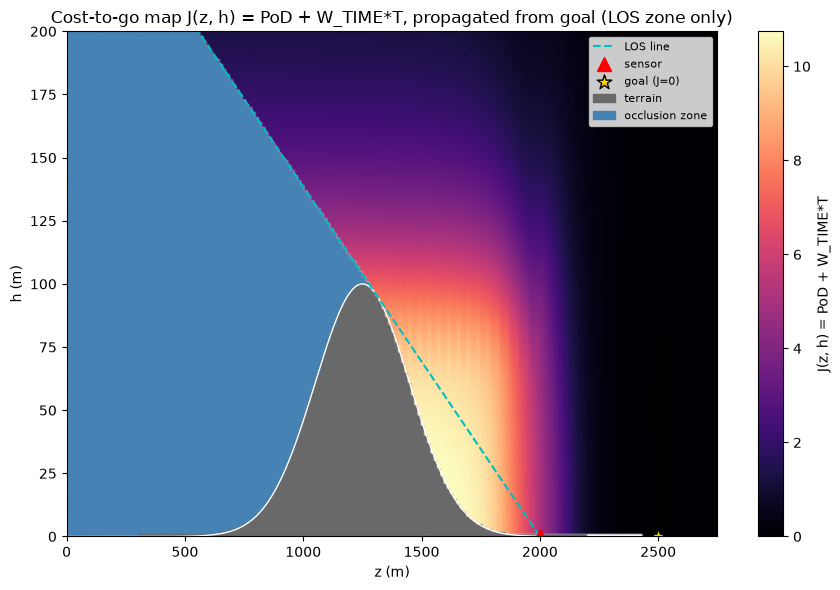

In [12]:
# STEP 6-1 PLOT — Cost-to-Go Map (load costmap_2d.json, no recompute)
#
# Single (z, h) heatmap of J(z, h): the goal cell (Z_GOAL, H_GOAL) is cost 0,
# and cost accumulates outward as cells require more stage cost to reach the
# goal. Terrain (gray) and the occlusion zone (steel blue, excluded from the
# Dijkstra graph since this map covers the LOS zone only) are drawn as flat
# background colors so they read as distinct regions rather than both NaN.
# Terrain is drawn last so it takes precedence where the ridge itself falls
# inside the occlusion zone (z < z_tangent).
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np

costmap_path = os.path.join(DATA_DIR, 'costmap_2d.json')
with open(costmap_path, 'r') as f:
    cm = json.load(f)

terrain_path = os.path.join(DATA_DIR, 'terrain.json')
with open(terrain_path, 'r') as f:
    terrain_data = json.load(f)

z_grid = np.array(cm['z_grid'])
h_grid = np.array(cm['h_grid'])
J_2D = np.array(cm['J_2D'])
terrain_mask_2d = np.array(cm['terrain_mask_2d'], dtype=bool)
occlusion_mask_2d = np.array(cm['occlusion_mask_2d'], dtype=bool)
exclude_mask = np.array(cm['exclude_mask_2d'], dtype=bool)

z_terrain = np.array(terrain_data['z_grid'])
h_terrain_vals = np.array(terrain_data['h_terrain'])
LOS = terrain_data['LOS']

TERRAIN_COLOR = 'dimgray'
OCCLUSION_COLOR = 'steelblue'

background = np.zeros((len(z_grid), len(h_grid), 4))
background[occlusion_mask_2d] = mcolors.to_rgba(OCCLUSION_COLOR)
background[terrain_mask_2d] = mcolors.to_rgba(TERRAIN_COLOR)

J_plot = np.where(np.isfinite(J_2D) & ~exclude_mask, J_2D, np.nan)
cmap = plt.get_cmap('magma').copy()
cmap.set_bad(color=(1, 1, 1, 0))

extent = (z_grid[0], z_grid[-1], h_grid[0], h_grid[-1])
plt.figure(figsize=(9, 6))
plt.imshow(np.transpose(background, (1, 0, 2)), origin='lower', extent=extent, aspect='auto')
im = plt.imshow(J_plot.T, origin='lower', extent=extent, aspect='auto', cmap=cmap)
plt.colorbar(im, label='J(z, h) = PoD + W_TIME*T')

plt.plot(z_terrain, h_terrain_vals, 'w-', lw=1.0)
los_line = LOS['slope'] * z_grid + LOS['intercept']
plt.plot(z_grid, los_line, 'c--', lw=1.5, label='LOS line')
plt.plot(params['Z_SENSOR'], params['H_SENSOR'], 'r^', markersize=10, label='sensor')
plt.scatter([params['Z_GOAL']], [params['H_GOAL']], c='gold', s=120, marker='*', edgecolors='k', label='goal (J=0)')

legend_handles, legend_labels = plt.gca().get_legend_handles_labels()
legend_handles += [mpatches.Patch(color=TERRAIN_COLOR, label='terrain'),
                    mpatches.Patch(color=OCCLUSION_COLOR, label='occlusion zone')]
plt.legend(handles=legend_handles, loc='upper right', fontsize=8)

plt.xlabel('z (m)')
plt.ylabel('h (m)')
plt.xlim(z_grid[0], z_grid[-1])
plt.ylim(h_grid[0], h_grid[-1])
plt.title('Cost-to-go map J(z, h) = PoD + W_TIME*T, propagated from goal (LOS zone only)')
plt.tight_layout()
plt.show()

### Step 6-1b: Does the Time Penalty Actually Change Anything?

The combined-`J` heatmap above looks visually identical to the old pure-PoD
map -- that's expected, since `W_TIME*DT_DP` per stage is tiny next to
typical PoD values (deliberately, so time never overrides a real safety
trade-off). The map *values* did shift everywhere, but not by enough to see
on a colorbar spanning `[0, ~10.7]`.

The real, checkable effect is on the **policy**: at how many `(z,h)` cells
does the optimal next heading actually change once the time term is added?
Re-run Dijkstra with `W_TIME=0` (pure PoD) and diff the resulting greedy
policy against the `W_TIME=1e-3` policy, cell by cell.


In [13]:
# STEP 6-1b COMPUTE — Policy Diff: PoD-only (W_TIME=0) vs PoD + W_TIME*T
#
# Reuses c_lagged/valid_lagged/exclude_mask/etc. from Step 6-1 COMPUTE above.
# Re-runs Dijkstra with W_TIME=0 to get a pure-PoD baseline, then compares
# the resulting greedy policy (best next action per cell) against the
# combined-J policy already computed (`dist`, params['W_TIME']).

rev_adj_podonly = {}
for iz in range(NZ):
    for ih in range(NH):
        if exclude_mask[iz, ih]:
            continue
        src = flat2(iz, ih)
        z0 = float(z_grid[iz])
        for ig_a in range(NG):
            if not valid_lagged[iz, ih, ig_a]:
                continue
            z1 = z0 + dz_per_action[ig_a] * n_sub
            h1 = float(h_grid[ih])
            for _ in range(n_sub):
                h1 = max(h1 + dh_per_action[ig_a], 0.0)
            iz_n = nearest_idx(z_grid, z1)
            ih_n = nearest_idx(h_grid, h1)
            if exclude_mask[iz_n, ih_n]:
                continue
            dst = flat2(iz_n, ih_n)
            weight = float(c_lagged[iz, ih, ig_a])  # no time penalty
            rev_adj_podonly.setdefault(dst, []).append((src, weight))

dist_podonly = np.full(N_STATES_2D, np.inf)
visited_podonly = np.zeros(N_STATES_2D, dtype=bool)
dist_podonly[goal_flat] = 0.0
heap = [(0.0, goal_flat)]
while heap:
    d, u = heapq.heappop(heap)
    if visited_podonly[u]:
        continue
    visited_podonly[u] = True
    for v, w in rev_adj_podonly.get(u, []):
        nd = d + w
        if nd < dist_podonly[v]:
            dist_podonly[v] = nd
            heapq.heappush(heap, (nd, v))


def best_action_map(dist_arr, w_time):
    """Greedy optimal next action index per (iz,ih), -1 if unreachable/dead-end."""
    policy = np.full((NZ, NH), -1, dtype=int)
    for iz in range(NZ):
        for ih in range(NH):
            if exclude_mask[iz, ih]:
                continue
            z0 = float(z_grid[iz])
            h0 = float(h_grid[ih])
            best_a, best_total = -1, np.inf
            for ig_a in range(NG):
                if not valid_lagged[iz, ih, ig_a]:
                    continue
                z1 = z0 + dz_per_action[ig_a] * n_sub
                h1 = h0
                for _ in range(n_sub):
                    h1 = max(h1 + dh_per_action[ig_a], 0.0)
                iz_n = nearest_idx(z_grid, z1)
                ih_n = nearest_idx(h_grid, h1)
                if exclude_mask[iz_n, ih_n]:
                    continue
                total = float(c_lagged[iz, ih, ig_a]) + w_time * params['DT_DP'] + dist_arr[flat2(iz_n, ih_n)]
                if total < best_total:
                    best_total = total
                    best_a = ig_a
            policy[iz, ih] = best_a
    return policy


policy_podonly = best_action_map(dist_podonly, 0.0)
policy_combined = best_action_map(dist, params['W_TIME'])

reachable_2d = np.isfinite(dist_podonly).reshape(NZ, NH) & np.isfinite(dist).reshape(NZ, NH) & (~exclude_mask)
policy_diff_mask = (policy_podonly != policy_combined) & reachable_2d

n_reachable = int(reachable_2d.sum())
n_diff = int(policy_diff_mask.sum())
print(f'reachable cells: {n_reachable}')
print(f'cells where optimal action differs (PoD-only vs PoD+W_TIME*T): {n_diff} ({100 * n_diff / n_reachable:.2f}%)')

policy_diff_data = {
    'z_grid': z_grid.tolist(),
    'h_grid': h_grid.tolist(),
    'exclude_mask_2d': exclude_mask.tolist(),
    'reachable_mask_2d': reachable_2d.tolist(),
    'policy_diff_mask_2d': policy_diff_mask.tolist(),
    'n_reachable': n_reachable,
    'n_diff': n_diff,
    'goal_cell': [iz_goal, ih_goal],
}
policy_diff_path = os.path.join(DATA_DIR, 'policy_diff.json')
with open(policy_diff_path, 'w') as f:
    json.dump(policy_diff_data, f, indent=2)
print('policy diff saved to', policy_diff_path)


reachable cells: 22366
cells where optimal action differs (PoD-only vs PoD+W_TIME*T): 146 (0.65%)
policy diff saved to D:\git\git_research\glider_hybrid_control\p1b\data\policy_diff.json


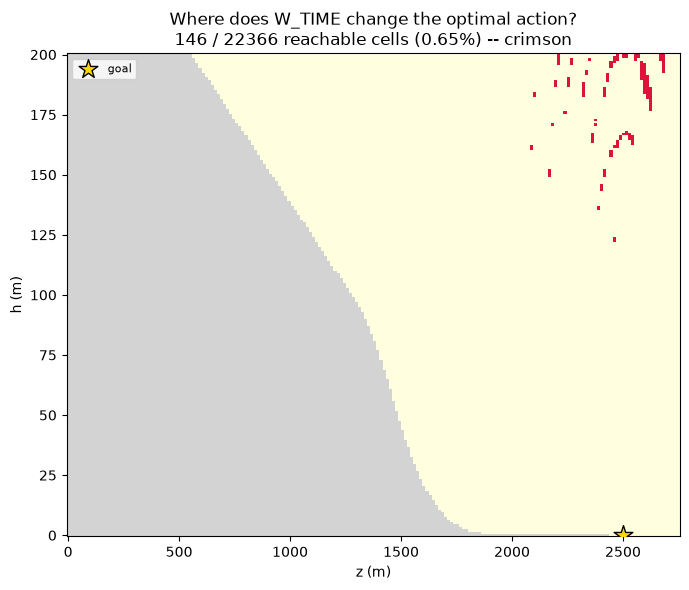

In [14]:
# STEP 6-1b PLOT — Policy Diff Map (load policy_diff.json, no recompute)
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

policy_diff_path = os.path.join(DATA_DIR, 'policy_diff.json')
with open(policy_diff_path, 'r') as f:
    pd_data = json.load(f)

z_grid_pd = np.array(pd_data['z_grid'])
h_grid_pd = np.array(pd_data['h_grid'])
exclude_mask_pd = np.array(pd_data['exclude_mask_2d'], dtype=bool)
diff_mask_pd = np.array(pd_data['policy_diff_mask_2d'], dtype=bool)
reachable_mask_pd = np.array(pd_data['reachable_mask_2d'], dtype=bool)
iz_goal_pd, ih_goal_pd = pd_data['goal_cell']

img = np.zeros(exclude_mask_pd.shape)  # 0 = excluded (terrain/occlusion)
img[reachable_mask_pd] = 1             # 1 = reachable, same optimal action
img[diff_mask_pd] = 2                  # 2 = reachable, optimal action differs

fig, ax = plt.subplots(figsize=(7, 6))
cmap = ListedColormap(['lightgray', 'lightyellow', 'crimson'])
ax.pcolormesh(z_grid_pd, h_grid_pd, img.T, cmap=cmap, vmin=0, vmax=2, shading='auto')
ax.scatter([z_grid_pd[iz_goal_pd]], [h_grid_pd[ih_goal_pd]], c='gold', marker='*', s=200,
           edgecolors='k', zorder=5, label='goal')
ax.set_xlabel('z (m)')
ax.set_ylabel('h (m)')
ax.set_title(
    f"Where does W_TIME change the optimal action?\n"
    f"{pd_data['n_diff']} / {pd_data['n_reachable']} reachable cells "
    f"({100 * pd_data['n_diff'] / pd_data['n_reachable']:.2f}%) -- crimson"
)
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


Step 6-2 executes the `(z,h)` cost-to-go map closed-loop: at every stage
(including the first), the real `(z, h)` is used to try every heading with
real point-mass kinematics (`glider_dynamics_pointmass`) and pick whichever
minimizes `stage_cost + J(resulting cell)` (`best_action`). Because speed is
constant and heading has no inertia, this greedy one-stage-lookahead
re-query is exact for this model -- `(z,h)` fully determines what's
reachable next, so there is nothing about "how we got here" that the policy
could fail to account for (this is the property that broke down when the
same closed-loop scheme was tried on the fixed-wing model: there, the real
`v,gamma` at arrival could differ from whatever the cost-to-go map's
best-case projection assumed, occasionally leading to genuine dead ends).

The powered phase flies at the same constant speed (`V_LAUNCH`, straight
line to the switching point) and the glide phase continues at that same
speed with freely chosen heading each stage -- there is no separate
"entry condition" to bridge; `best_action` handles the real (possibly
off-grid) state the same way at every step, including the first.


In [15]:
# STEP 6-2 COMPUTE — Optimal Switching Point + Full Mission Trajectory
# Point-mass BASELINE: closed-loop / receding-horizon execution over the
# (z,h) cost-to-go map. Since (z,h) is genuinely Markov for this model
# (constant speed, no-inertia heading reset), re-querying the best action
# from the real current (z,h) every stage is both correct and exact --
# there is no risk of the policy "promising" something the real state can't
# deliver (unlike the fixed-wing model).
#
# Objective: matches Step 6-1's J = PoD + W_TIME*T -- best_action adds the
# same W_TIME*DT_DP time penalty per stage before comparing against J(next
# cell), so the closed-loop re-query stays consistent with the map it reads
# from. Reported "PoD" is NOT a running sum of stage_pod -- summing bounded
# [0,1) probabilities is not itself a probability and can exceed 1. Instead
# each stage's raw hazard integral (stage_hazard = lam_sum*dt_glide) is
# accumulated additively (hazard integrals over disjoint time intervals ARE
# exactly additive, unlike probabilities), and PoD is recovered via
# 1-exp(-cum_hazard) only where a bounded probability is actually needed
# (per-substep interpolation in PLOT 4's curve, and the final total).
import math
import numpy as np

costmap_path = os.path.join(DATA_DIR, 'costmap_2d.json')
with open(costmap_path, 'r') as f:
    cm = json.load(f)
state_path = os.path.join(DATA_DIR, 'costmap_2d_state.npz')
state_npz = np.load(state_path)
dist = state_npz['dist']

terrain_path = os.path.join(DATA_DIR, 'terrain.json')
with open(terrain_path, 'r') as f:
    terrain_data = json.load(f)
switching_candidates = terrain_data['switching_candidates']
LOS = terrain_data['LOS']
sensor_list = [(params['Z_SENSOR'], params['H_SENSOR'])]

z_grid = np.array(cm['z_grid'])
h_grid = np.array(cm['h_grid'])
gamma_grid = np.array(cm['gamma_grid'])
exclude_mask = np.array(cm['exclude_mask_2d'], dtype=bool)
iz_goal, ih_goal = cm['goal_cell']
NZ, NH = len(z_grid), len(h_grid)

n_sub = int(round(params['DT_DP'] / params['DT_GLIDE']))
dt_glide = params['DT_GLIDE']
v_pm = params['V_LAUNCH']


def nearest_idx(grid, val):
    step = grid[1] - grid[0]
    idx = int(round((val - grid[0]) / step))
    return int(np.clip(idx, 0, len(grid) - 1))


def flat2(iz, ih):
    return iz * NH + ih


def best_action(z0, h0, v0, gamma0_rad, params):
    """
    Closed-loop policy query: given the real current (z,h), try every action
    with the real point-mass kinematics (substep-by-substep, with the same
    within-stage terrain/ground validity check as the cost sweep), and pick
    whichever minimizes stage_cost + J(resulting cell). Returns None if every
    action is either terrain-clipped or invalid.
    """
    best = None
    for ig_a, gamma_a_deg in enumerate(gamma_grid):
        gamma_a_rad = float(np.radians(gamma_a_deg))
        state = (float(z0), float(h0), v_pm, gamma_a_rad)
        lam_sum = 0.0
        clipped = False
        substates = []
        for _ in range(n_sub):
            state = glider_dynamics_pointmass(state, gamma_a_rad, params)
            z, h, v, gr = state
            if h < h_terrain(z, params) - 1e-6 or h < -1e-6:
                clipped = True
                break
            lam_sum += lambda_total_fn(z, h, v, float(np.degrees(gr)), sensor_list, 'glide', LOS, params)
            substates.append(state)
        if clipped:
            continue
        stage_hazard = lam_sum * dt_glide           # raw hazard integral this stage (exact, additive)
        stage_pod = 1.0 - math.exp(-stage_hazard)   # single-stage detection probability
        stage_J = stage_pod + params['W_TIME'] * params['DT_DP']
        z1, h1, v1, gamma1_rad = state
        iz1, ih1 = nearest_idx(z_grid, z1), nearest_idx(h_grid, h1)
        if exclude_mask[iz1, ih1]:
            continue
        total = stage_J + float(dist[flat2(iz1, ih1)])
        if not np.isfinite(total):
            continue
        if best is None or total < best['J']:
            best = {
                'J': total, 'action_gamma_deg': float(gamma_a_deg), 'stage_pod': stage_pod,
                'stage_hazard': stage_hazard, 'stage_J': stage_J,
                'next_cell': (iz1, ih1), 'next_state': state, 'substates': substates,
            }
    return best


def fly_closed_loop(z0, h0, v0, gamma0_rad, params, max_hops=2000):
    """
    Repeatedly call best_action from the real resulting state every stage,
    until the snapped cell reaches the exact goal cell (iz_goal, ih_goal).
    """
    t_list, z_list, h_list, v_list, g_list, cost_list, pod_list = [0.0], [z0], [h0], [v0], [math.degrees(gamma0_rad)], [0.0], [0.0]
    state = (z0, h0, v0, gamma0_rad)
    t = 0.0
    cum_J = 0.0
    cum_hazard = 0.0   # additive across stages (hazard integrals sum exactly); PoD = 1-exp(-cum_hazard)
    first_action = None
    hop = 0
    iz_cur, ih_cur = nearest_idx(z_grid, z0), nearest_idx(h_grid, h0)
    while not (iz_cur == iz_goal and ih_cur == ih_goal) and hop < max_hops:
        hop += 1
        step = best_action(state[0], state[1], state[2], state[3], params)
        if step is None:
            return None
        if first_action is None:
            first_action = step['action_gamma_deg']
        n_sub_actual = len(step['substates'])
        for k, s in enumerate(step['substates']):
            t += dt_glide
            frac = (k + 1) / n_sub_actual
            cost_list.append(cum_J + frac * step['stage_J'])
            pod_list.append(1.0 - math.exp(-(cum_hazard + frac * step['stage_hazard'])))
            t_list.append(t)
            z_list.append(s[0]); h_list.append(s[1]); v_list.append(s[2]); g_list.append(math.degrees(s[3]))
        cum_J += step['stage_J']
        cum_hazard += step['stage_hazard']
        iz_cur, ih_cur = step['next_cell']
        state = step['next_state']
    if not (iz_cur == iz_goal and ih_cur == ih_goal):
        return None   # hit max_hops without ever reaching the goal cell -- treat as unreachable, not a (deceptively low) partial J
    return {
        't': t_list, 'z': z_list, 'h': h_list, 'v': v_list, 'gamma': g_list, 'cost': cost_list, 'pod': pod_list,
        'J': cum_J, 'pod_total': 1.0 - math.exp(-cum_hazard), 'first_action_gamma_deg': first_action,
    }


# --- Glide trajectory for every switching candidate, entering the LOS zone
# at the powered-phase ending point, executed closed-loop to the goal. ---
candidate_results = []
for z_sw, h_sw in switching_candidates:
    if h_sw > params['H_MAX_GRID']:
        candidate_results.append({
            'z_sw': float(z_sw), 'h_sw': float(h_sw), 'J': float('inf'), 'reachable': False,
            'path_z': [float(z_sw)], 'path_h': [float(h_sw)], 'path_t': [0.0], 'path_pod': [0.0],
        })
        continue

    powered_states = powered_trajectory(z_sw, h_sw, params)
    v_entry, gamma_entry_rad = powered_states[-1][2], powered_states[-1][3]
    flight = fly_closed_loop(z_sw, h_sw, v_entry, gamma_entry_rad, params)
    if flight is None:
        candidate_results.append({
            'z_sw': float(z_sw), 'h_sw': float(h_sw), 'J': float('inf'), 'reachable': False,
            'path_z': [float(z_sw)], 'path_h': [float(h_sw)], 'path_t': [0.0], 'path_pod': [0.0],
        })
        continue

    candidate_results.append({
        'z_sw': float(z_sw), 'h_sw': float(h_sw), 'J': flight['J'], 'pod_total': flight['pod_total'], 'reachable': True,
        'first_action_gamma_deg': flight['first_action_gamma_deg'],
        'path_z': flight['z'], 'path_h': flight['h'],
        'path_t': flight['t'], 'path_pod': flight['pod'],
    })

n_reachable = sum(c['reachable'] for c in candidate_results)
print(f'{n_reachable} / {len(candidate_results)} switching candidates land inside the grid (h_sw <= H_MAX_GRID)')

reachable_results = [c for c in candidate_results if c['reachable']]
if not reachable_results:
    raise RuntimeError(f'No switching candidate actually reached the goal cell within max_hops at this grid resolution (NZ={NZ}, NH={NH}). The grid may be too coarse for this gamma range -- try a finer grid.')
best = min(reachable_results, key=lambda c: c['J'])
best_idx = candidate_results.index(best)
z_sw_star, h_sw_star = best['z_sw'], best['h_sw']
print(f'optimal switching point: (z={z_sw_star:.1f}, h={h_sw_star:.1f}), J={best["J"]:.4f}  [candidate {best_idx}]')

# --- Optimal powered phase: straight line, launch -> (z_sw*, h_sw*) ---
powered_states = powered_trajectory(z_sw_star, h_sw_star, params)
dt_pow = params['DT_POW']
t_pow = [i * dt_pow for i in range(len(powered_states))]
z_pow = [s[0] for s in powered_states]
h_pow = [s[1] for s in powered_states]
v_pow = [s[2] for s in powered_states]
gamma_pow = [float(np.degrees(s[3])) for s in powered_states]

# --- Optimal glide phase: re-run the closed-loop flight once more for the
# best candidate to get the full state history. ---
powered_end_state = powered_states[-1]
flight_full = fly_closed_loop(z_sw_star, h_sw_star, powered_end_state[2], powered_end_state[3], params)
t_glide = [t + t_pow[-1] for t in flight_full['t']]
z_glide = flight_full['z']
h_glide = flight_full['h']
v_glide = flight_full['v']
gamma_glide = flight_full['gamma']
cost_glide = flight_full['cost']
pod_glide = flight_full['pod']

# --- Concatenate full mission trajectory (powered + glide) ---
t_full = t_pow + t_glide[1:]
z_full = z_pow + z_glide[1:]
h_full = h_pow + h_glide[1:]
v_full = v_pow + v_glide[1:]
gamma_full = gamma_pow + gamma_glide[1:]
cost_full = [0.0] * len(t_pow) + cost_glide[1:]
pod_full = [0.0] * len(t_pow) + pod_glide[1:]

print(f'powered phase: {len(t_pow)} steps, glide phase: {len(t_glide) - 1} steps, total t = {t_full[-1]:.0f} s')
print(f'final state: z={z_full[-1]:.1f}, h={h_full[-1]:.1f}, '
      f'cumulative PoD={pod_full[-1]:.4f}, W_TIME*T={params["W_TIME"]*t_full[-1]:.4f}, combined J={cost_full[-1]:.4f}')

step6_2_data = {
    'params': params,
    'candidates': candidate_results,
    'best_idx': best_idx,
    'switching_point': [z_sw_star, h_sw_star],
    'powered_end_index': len(t_pow) - 1,
    't_traj': t_full,
    'z_traj': z_full,
    'h_traj': h_full,
    'v_traj': v_full,
    'gamma_traj': gamma_full,
    'cost_traj': cost_full,
    'pod_traj': pod_full,
}

step6_2_path = os.path.join(DATA_DIR, 'step6_2.json')
with open(step6_2_path, 'w') as f:
    json.dump(step6_2_data, f, indent=2)
print('Step 6-2 data saved to', step6_2_path)

11 / 20 switching candidates land inside the grid (h_sw <= H_MAX_GRID)
optimal switching point: (z=592.1, h=195.1), J=1.5015  [candidate 9]
powered phase: 31 steps, glide phase: 96 steps, total t = 126 s
final state: z=2505.0, h=0.0, cumulative PoD=0.7669, W_TIME*T=0.1260, combined J=1.5015
Step 6-2 data saved to D:\git\git_research\glider_hybrid_control\p1b\data\step6_2.json


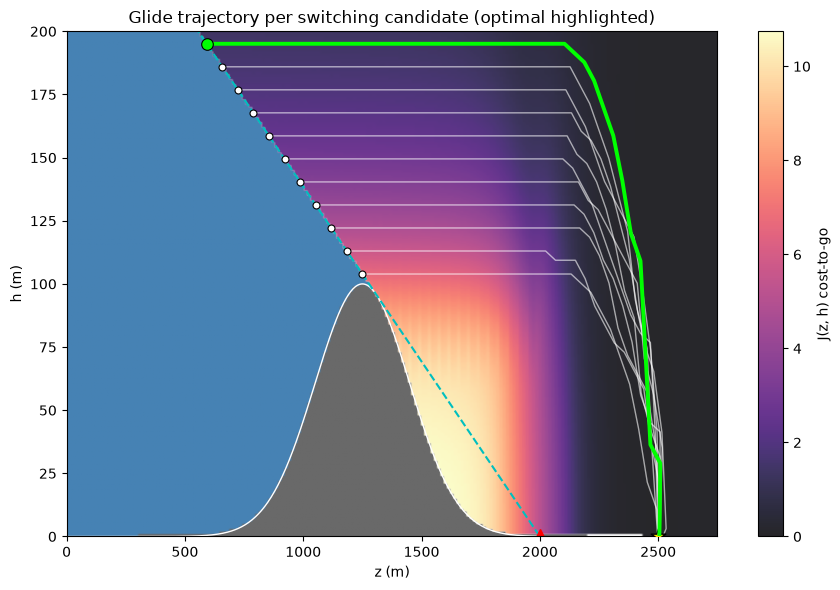

In [16]:
# STEP 6-2 PLOT 1 — Switching-Candidate Glide Trajectory Comparison (load step6_2.json, no recompute)
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np

costmap_path = os.path.join(DATA_DIR, 'costmap_2d.json')
with open(costmap_path, 'r') as f:
    cm = json.load(f)
step6_2_path = os.path.join(DATA_DIR, 'step6_2.json')
with open(step6_2_path, 'r') as f:
    s62 = json.load(f)
terrain_path = os.path.join(DATA_DIR, 'terrain.json')
with open(terrain_path, 'r') as f:
    terrain_data = json.load(f)

z_grid = np.array(cm['z_grid'])
h_grid = np.array(cm['h_grid'])
J_2D = np.array(cm['J_2D'])
terrain_mask_2d = np.array(cm['terrain_mask_2d'], dtype=bool)
occlusion_mask_2d = np.array(cm['occlusion_mask_2d'], dtype=bool)
exclude_mask = np.array(cm['exclude_mask_2d'], dtype=bool)
z_terrain = np.array(terrain_data['z_grid'])
h_terrain_vals = np.array(terrain_data['h_terrain'])
LOS = terrain_data['LOS']

candidates = s62['candidates']
best_idx = s62['best_idx']

TERRAIN_COLOR = 'dimgray'
OCCLUSION_COLOR = 'steelblue'
background = np.zeros((len(z_grid), len(h_grid), 4))
background[occlusion_mask_2d] = mcolors.to_rgba(OCCLUSION_COLOR)
background[terrain_mask_2d] = mcolors.to_rgba(TERRAIN_COLOR)

J_plot = np.where(np.isfinite(J_2D) & ~exclude_mask, J_2D, np.nan)
cmap = plt.get_cmap('magma').copy()
cmap.set_bad(color=(1, 1, 1, 0))
extent = (z_grid[0], z_grid[-1], h_grid[0], h_grid[-1])

plt.figure(figsize=(9, 6))
plt.imshow(np.transpose(background, (1, 0, 2)), origin='lower', extent=extent, aspect='auto')
im = plt.imshow(J_plot.T, origin='lower', extent=extent, aspect='auto', cmap=cmap, alpha=0.85)
plt.colorbar(im, label='J(z, h) cost-to-go')

plt.plot(z_terrain, h_terrain_vals, 'w-', lw=1.0)
los_line = LOS['slope'] * z_grid + LOS['intercept']
plt.plot(z_grid, los_line, 'c--', lw=1.5, label='LOS line')
plt.plot(params['Z_SENSOR'], params['H_SENSOR'], 'r^', markersize=10, label='sensor')
plt.scatter([params['Z_GOAL']], [params['H_GOAL']], c='gold', s=120, marker='*', edgecolors='k', zorder=5, label='goal (J=0)')

for idx, c in enumerate(candidates):
    if not c['reachable']:
        plt.scatter([c['z_sw']], [c['h_sw']], c='gray', marker='x', s=40, zorder=4,
                    label='unreachable candidate (h_sw > H_MAX_GRID)' if idx == 0 else None)
        continue
    is_best = (idx == best_idx)
    plt.plot(c['path_z'], c['path_h'],
              color='lime' if is_best else 'white',
              lw=2.8 if is_best else 1.0,
              alpha=1.0 if is_best else 0.6,
              zorder=6 if is_best else 3,
              label=f'optimal glide (J={c["J"]:.3f})' if is_best else None)
    plt.scatter([c['z_sw']], [c['h_sw']],
                c='lime' if is_best else 'white',
                s=70 if is_best else 25,
                edgecolors='k', linewidths=0.8, zorder=7 if is_best else 4,
                label='optimal switching point' if is_best else None)

plt.xlabel('z (m)')
plt.ylabel('h (m)')
plt.xlim(z_grid[0], z_grid[-1])
plt.ylim(h_grid[0], h_grid[-1])
plt.title('Glide trajectory per switching candidate (optimal highlighted)')
legend_handles, legend_labels = plt.gca().get_legend_handles_labels()
legend_handles += [mpatches.Patch(color=TERRAIN_COLOR, label='terrain'),
                    mpatches.Patch(color=OCCLUSION_COLOR, label='occlusion zone')]
# plt.legend(handles=legend_handles, loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

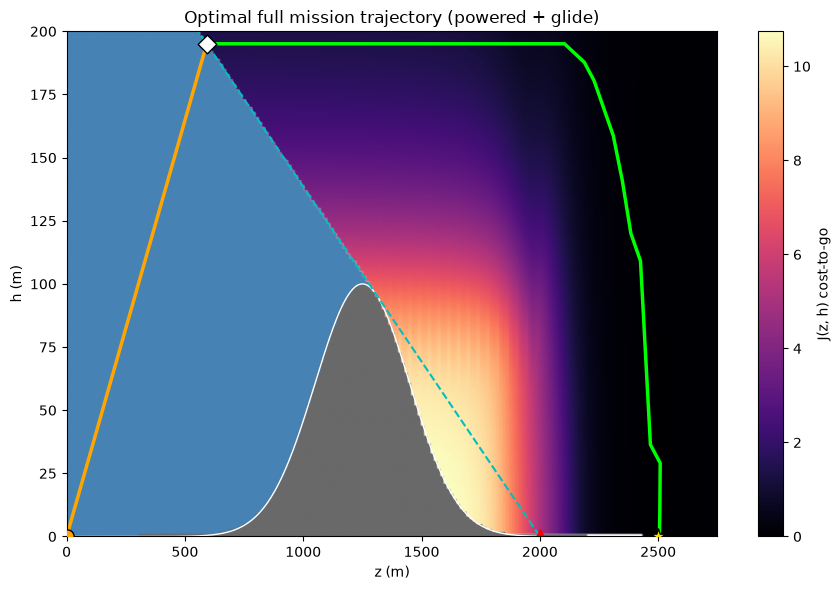

In [17]:
# STEP 6-2 PLOT 2 — Optimal Full Mission Trajectory (load step6_2.json, no recompute)
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np

costmap_path = os.path.join(DATA_DIR, 'costmap_2d.json')
with open(costmap_path, 'r') as f:
    cm = json.load(f)
step6_2_path = os.path.join(DATA_DIR, 'step6_2.json')
with open(step6_2_path, 'r') as f:
    s62 = json.load(f)
terrain_path = os.path.join(DATA_DIR, 'terrain.json')
with open(terrain_path, 'r') as f:
    terrain_data = json.load(f)

z_grid = np.array(cm['z_grid'])
h_grid = np.array(cm['h_grid'])
J_2D = np.array(cm['J_2D'])
terrain_mask_2d = np.array(cm['terrain_mask_2d'], dtype=bool)
occlusion_mask_2d = np.array(cm['occlusion_mask_2d'], dtype=bool)
exclude_mask = np.array(cm['exclude_mask_2d'], dtype=bool)
z_terrain = np.array(terrain_data['z_grid'])
h_terrain_vals = np.array(terrain_data['h_terrain'])
LOS = terrain_data['LOS']

z_traj = np.array(s62['z_traj'])
h_traj = np.array(s62['h_traj'])
powered_end = s62['powered_end_index']
z_sw, h_sw = s62['switching_point']

TERRAIN_COLOR = 'dimgray'
OCCLUSION_COLOR = 'steelblue'
background = np.zeros((len(z_grid), len(h_grid), 4))
background[occlusion_mask_2d] = mcolors.to_rgba(OCCLUSION_COLOR)
background[terrain_mask_2d] = mcolors.to_rgba(TERRAIN_COLOR)

J_plot = np.where(np.isfinite(J_2D) & ~exclude_mask, J_2D, np.nan)
cmap = plt.get_cmap('magma').copy()
cmap.set_bad(color=(1, 1, 1, 0))
extent = (z_grid[0], z_grid[-1], h_grid[0], h_grid[-1])

plt.figure(figsize=(9, 6))
plt.imshow(np.transpose(background, (1, 0, 2)), origin='lower', extent=extent, aspect='auto')
im = plt.imshow(J_plot.T, origin='lower', extent=extent, aspect='auto', cmap=cmap)
plt.colorbar(im, label='J(z, h) cost-to-go')

plt.plot(z_terrain, h_terrain_vals, 'w-', lw=1.0)
los_line = LOS['slope'] * z_grid + LOS['intercept']
plt.plot(z_grid, los_line, 'c--', lw=1.5, label='LOS line')
plt.plot(params['Z_SENSOR'], params['H_SENSOR'], 'r^', markersize=10, label='sensor')

plt.plot(z_traj[:powered_end + 1], h_traj[:powered_end + 1], color='orange', lw=2.5, label='powered phase')
plt.plot(z_traj[powered_end:], h_traj[powered_end:], color='lime', lw=2.5, label='glide phase')

plt.scatter([params['Z_LAUNCH']], [params['H_LAUNCH']], c='orange', s=90, marker='o', edgecolors='k', zorder=6, label='launch')
plt.scatter([z_sw], [h_sw], c='white', s=90, marker='D', edgecolors='k', zorder=6, label='switching point')
plt.scatter([params['Z_GOAL']], [params['H_GOAL']], c='gold', s=120, marker='*', edgecolors='k', zorder=6, label='goal (J=0)')

legend_handles, legend_labels = plt.gca().get_legend_handles_labels()
legend_handles += [mpatches.Patch(color=TERRAIN_COLOR, label='terrain'),
                    mpatches.Patch(color=OCCLUSION_COLOR, label='occlusion zone')]
# plt.legend(handles=legend_handles, loc='upper right', fontsize=8)

plt.xlabel('z (m)')
plt.ylabel('h (m)')
plt.xlim(z_grid[0], z_grid[-1])
plt.ylim(h_grid[0], h_grid[-1])
plt.title('Optimal full mission trajectory (powered + glide)')
plt.tight_layout()
plt.show()

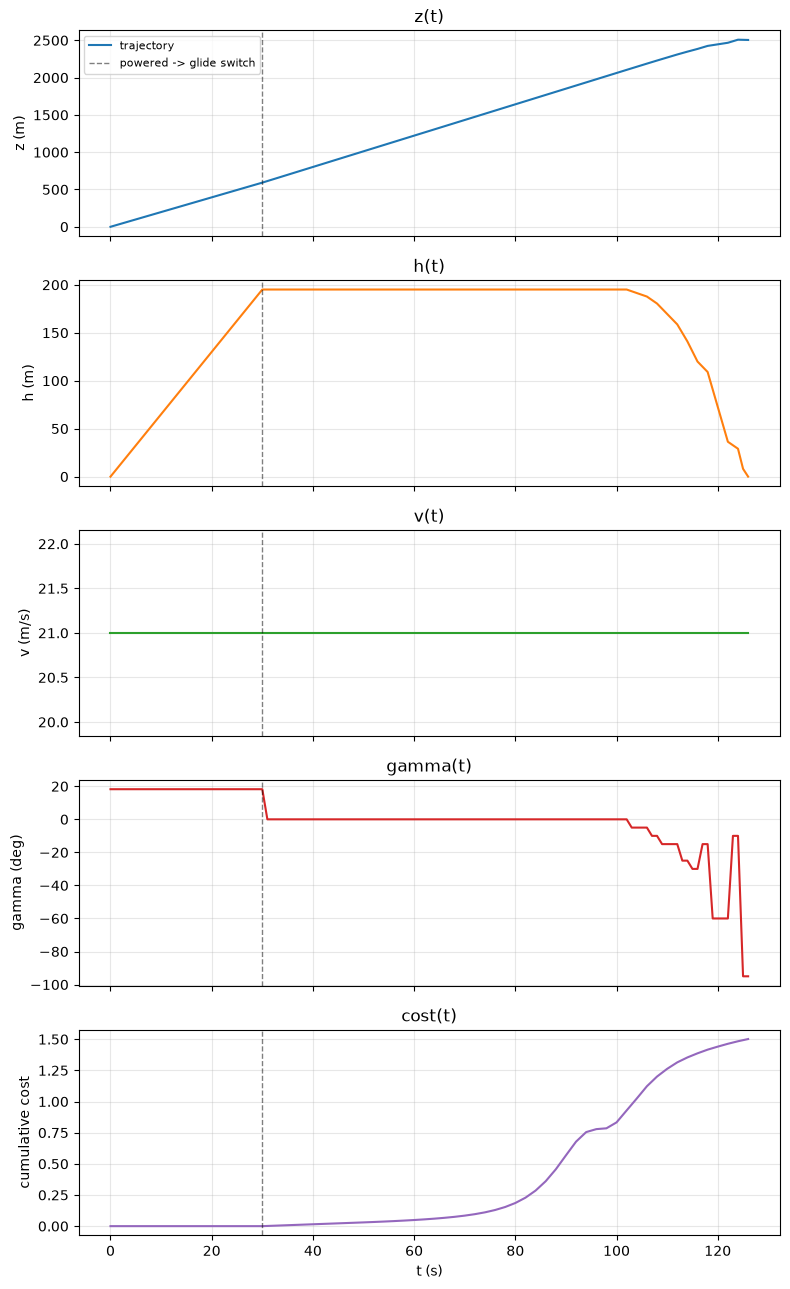

In [18]:
# STEP 6-2 PLOT 3 — Optimal Trajectory State Histories (load step6_2.json, no recompute)
import matplotlib.pyplot as plt
import numpy as np

step6_2_path = os.path.join(DATA_DIR, 'step6_2.json')
with open(step6_2_path, 'r') as f:
    s62 = json.load(f)

t_traj = np.array(s62['t_traj'])
z_traj = np.array(s62['z_traj'])
h_traj = np.array(s62['h_traj'])
v_traj = np.array(s62['v_traj'])
gamma_traj = np.array(s62['gamma_traj'])
cost_traj = np.array(s62['cost_traj'])
t_switch = t_traj[s62['powered_end_index']]

fig, axes = plt.subplots(5, 1, figsize=(8, 13), sharex=True)

series = [
    (z_traj, 'z (m)', 'z(t)', 'tab:blue'),
    (h_traj, 'h (m)', 'h(t)', 'tab:orange'),
    (v_traj, 'v (m/s)', 'v(t)', 'tab:green'),
    (gamma_traj, 'gamma (deg)', 'gamma(t)', 'tab:red'),
    (cost_traj, 'cumulative cost', 'cost(t)', 'tab:purple'),
]

for ax, (y, ylabel, title, color) in zip(axes, series):
    ax.plot(t_traj, y, color=color, label='trajectory')
    ax.axvline(t_switch, color='k', ls='--', lw=1, alpha=0.5, label='powered -> glide switch')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

axes[0].legend(fontsize=8, loc='best')
axes[-1].set_xlabel('t (s)')
plt.tight_layout()
plt.show()

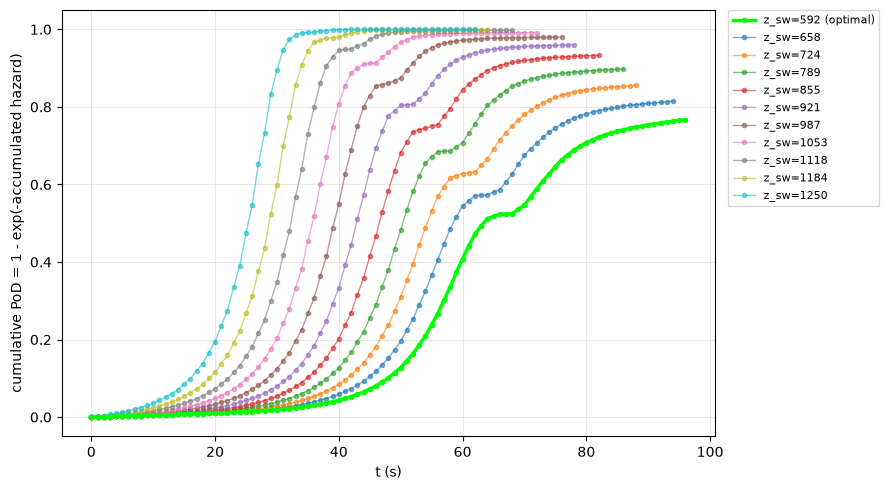

In [19]:
# STEP 6-2 PLOT 4 — Switching-Candidate t vs PoD Comparison (load step6_2.json, no recompute)
import matplotlib.pyplot as plt
import numpy as np

step6_2_path = os.path.join(DATA_DIR, 'step6_2.json')
with open(step6_2_path, 'r') as f:
    s62 = json.load(f)

candidates = s62['candidates']
best_idx = s62['best_idx']

plt.figure(figsize=(9, 5))
for idx, cand in enumerate(candidates):
    if not cand['reachable']:
        continue
    is_best = (idx == best_idx)
    plt.plot(cand['path_t'], cand['path_pod'],
              marker='o', markersize=3,
              color='lime' if is_best else None,
              lw=2.5 if is_best else 1.0,
              alpha=1.0 if is_best else 0.6,
              zorder=5 if is_best else 2,
              label=f'z_sw={cand["z_sw"]:.0f} (optimal)' if is_best else f'z_sw={cand["z_sw"]:.0f}')

plt.xlabel('t (s)')
plt.ylabel('cumulative PoD = 1 - exp(-accumulated hazard)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary: 2D Projected Cost-to-Go Map + Point-Mass Dijkstra

Everything above (Step 6-1, Step 6-2) is the **2D projected cost-to-go map
`J(z,h)`**, computed by running Dijkstra **directly on the 2D `(z,h)`
state** under the **point-mass** vehicle model (constant speed, no-inertia
heading reset every stage). This is valid because `(z,h)` alone is Markov
for this model -- there is no `v,gamma` "memory" that the 2D map could fail
to account for (see the Markov-property discussion above; this would NOT be
valid for the fixed-wing model, which needs the full `(z,h,v,gamma)` 4D
state and is left for a separate section).

The action set was extended to include **backward flight**
(`GAMMA_MIN_POINTMASS = -180`, vs. the original forward-only `-90`..`0`),
so a cell that overshoots past `Z_GOAL` is no longer structurally
unreachable -- it can fly back. With the sensor far from the goal
(`Z_SENSOR=2000`, baseline), this changes almost nothing about the optimal
path (overshooting was never advantageous anyway), but it fills in the
previously-blank "buffer zone" (`z > Z_GOAL`) of the heatmap and sets up
the action space needed below.

## Step 6-3: Sensitivity Test — Sensor Moved Closer to the Goal (`Z_SENSOR=2400`)

The cell below re-runs the same point-mass cost-to-go + closed-loop
pipeline with `Z_SENSOR` moved from `2000` to `2400` (much closer to
`Z_GOAL=2500`), reusing the same `(z,h)` grid, terrain, and action set
(including backward flight). With the sensor this close to the goal, the
glider can no longer count on a long, mostly-hidden glide followed by a
late dive -- it should either commit to a much steeper/earlier descent, or
make genuine use of the backward-flight capability to avoid passing too
close to the sensor while still descending. The output reports the optimal
switching point, whether the resulting path uses any backward
(`gamma < -90°`) action, and the final mission cost, so the two strategies
can be compared directly against the `Z_SENSOR=2000` baseline above.


In [20]:
# STEP 6-3 COMPUTE — Sensitivity Test: Z_SENSOR moved closer to Z_GOAL (2400)
#
# Re-runs the point-mass cost-to-go map (Step 6-1) and closed-loop mission
# (Step 6-2) with Z_SENSOR=2400 instead of the baseline 2000. Reuses the
# same (z,h) grid, terrain, and gamma_grid (including backward flight) --
# only the sensor position changes, which shifts the LOS occlusion line and
# every detection-rate evaluation. Uses the same J = PoD + W_TIME*T objective
# as Step 6-1/6-2 (see params cell W_TIME comment).
import heapq
import time

params_2400 = dict(params)
params_2400['Z_SENSOR'] = 2400.0

LOS_2400 = compute_LOS(params_2400['Z_SENSOR'], params_2400['H_SENSOR'], params_2400)
switching_candidates_2400 = get_switching_candidates(LOS_2400, params_2400, n_candidates=20)
sensor_list_2400 = [(params_2400['Z_SENSOR'], params_2400['H_SENSOR'])]

Z_grid_2400, H_grid_2400 = np.meshgrid(z_grid, h_grid, indexing='ij')
h_los_at_z_2400 = LOS_2400['slope'] * Z_grid_2400 + LOS_2400['intercept']
occlusion_mask_2d_2400 = (Z_grid_2400 < LOS_2400['z_tangent']) & (H_grid_2400 < h_los_at_z_2400)
exclude_mask_2400 = terrain_mask_2d | occlusion_mask_2d_2400

# --- Cost sweep: must be fully redone -- detection rate depends on sensor
# position everywhere, not just inside the occlusion mask. ---
cache_path_2400 = os.path.join(
    DATA_DIR, f'c_lagged_pointmass_cache_zsensor2400_{NZ}x{NH}_dtdp{params["DT_DP"]:.1f}'.replace('.', 'p') + '.npz')
if os.path.exists(cache_path_2400):
    cached = np.load(cache_path_2400)
    c_lagged_2400 = cached['c_lagged']
    valid_lagged_2400 = cached['valid_lagged']
    print('loaded cached c_lagged_2400, shape', c_lagged_2400.shape)
else:
    t0 = time.time()
    c_lagged_2400 = np.zeros((NZ, NH, NG))
    valid_lagged_2400 = np.ones((NZ, NH, NG), dtype=bool)
    for iz in range(NZ):
        z0 = float(z_grid[iz])
        for ih in range(NH):
            if exclude_mask_2400[iz, ih]:
                continue
            h0 = float(h_grid[ih])
            for ig_a, gamma_a_deg in enumerate(gamma_grid):
                z, h = z0, h0
                lam_sum = 0.0
                clipped = False
                for _ in range(n_sub):
                    z = z + dz_per_action[ig_a]
                    h = max(h + dh_per_action[ig_a], 0.0)
                    if h < h_terrain(z, params_2400) - 1e-6 or h < -1e-6:
                        clipped = True
                        break
                    lam_sum += lambda_total_fn(z, h, v_pm, float(gamma_a_deg), sensor_list_2400, 'glide', LOS_2400, params_2400)
                if clipped:
                    valid_lagged_2400[iz, ih, ig_a] = False
                else:
                    c_lagged_2400[iz, ih, ig_a] = 1.0 - math.exp(-lam_sum * dt)
        if iz % 50 == 0:
            print(f'  cost sweep (z_sensor=2400) iz={iz}/{NZ}, elapsed={time.time() - t0:.0f}s')
    print(f'cost sweep (z_sensor=2400) done in {time.time() - t0:.0f}s')
    np.savez_compressed(cache_path_2400, c_lagged=c_lagged_2400, valid_lagged=valid_lagged_2400)
    print('cached to', cache_path_2400)

# --- Graph + single-source Dijkstra (same structure as Step 6-1). ---
rev_adj_2400 = {}
for iz in range(NZ):
    for ih in range(NH):
        if exclude_mask_2400[iz, ih]:
            continue
        src = flat2(iz, ih)
        z0 = float(z_grid[iz])
        for ig_a in range(NG):
            if not valid_lagged_2400[iz, ih, ig_a]:
                continue
            z1 = z0 + dz_per_action[ig_a] * n_sub
            h1 = float(h_grid[ih])
            for _ in range(n_sub):
                h1 = max(h1 + dh_per_action[ig_a], 0.0)
            iz_n = nearest_idx(z_grid, z1)
            ih_n = nearest_idx(h_grid, h1)
            if exclude_mask_2400[iz_n, ih_n]:
                continue
            dst = flat2(iz_n, ih_n)
            weight = float(c_lagged_2400[iz, ih, ig_a]) + params_2400['W_TIME'] * params_2400['DT_DP']
            rev_adj_2400.setdefault(dst, []).append((src, weight))

dist_2400 = np.full(N_STATES_2D, np.inf)
visited_2400 = np.zeros(N_STATES_2D, dtype=bool)
dist_2400[goal_flat] = 0.0
heap = [(0.0, goal_flat)]
while heap:
    d, u = heapq.heappop(heap)
    if visited_2400[u]:
        continue
    visited_2400[u] = True
    for v, w in rev_adj_2400.get(u, []):
        nd = d + w
        if nd < dist_2400[v]:
            dist_2400[v] = nd
            heapq.heappush(heap, (nd, v))

finite_2400 = dist_2400[np.isfinite(dist_2400)]
print(f'z_sensor=2400: dist range (finite): [{finite_2400.min():.4f}, {finite_2400.max():.4f}], '
      f'reachable cells: {np.isfinite(dist_2400).sum()}/{N_STATES_2D}')

J_2D_2400 = dist_2400.reshape(NZ, NH).copy()
J_2D_2400[exclude_mask_2400] = np.inf

costmap_2400_data = {
    'params': params_2400,
    'z_grid': z_grid.tolist(), 'h_grid': h_grid.tolist(), 'gamma_grid': gamma_grid.tolist(),
    'terrain_mask_2d': terrain_mask_2d.tolist(), 'occlusion_mask_2d': occlusion_mask_2d_2400.tolist(),
    'exclude_mask_2d': exclude_mask_2400.tolist(), 'J_2D': J_2D_2400.tolist(), 'goal_cell': [iz_goal, ih_goal],
    'LOS': LOS_2400,
}
costmap_2400_path = os.path.join(DATA_DIR, 'costmap_2d_zsensor2400.json')
with open(costmap_2400_path, 'w') as f:
    json.dump(costmap_2400_data, f, indent=2)
state_2400_path = os.path.join(DATA_DIR, 'costmap_2d_state_zsensor2400.npz')
np.savez_compressed(state_2400_path, dist=dist_2400)
print('z_sensor=2400 cost-to-go map saved to', costmap_2400_path)


# --- Closed-loop execution (same structure as Step 6-2), against the new
# dist_2400 / exclude_mask_2400 / sensor_list_2400 / LOS_2400. ---
def best_action_2400(z0, h0, v0, gamma0_rad, params):
    best = None
    for ig_a, gamma_a_deg in enumerate(gamma_grid):
        gamma_a_rad = float(np.radians(gamma_a_deg))
        state = (float(z0), float(h0), v_pm, gamma_a_rad)
        lam_sum = 0.0
        clipped = False
        substates = []
        for _ in range(n_sub):
            state = glider_dynamics_pointmass(state, gamma_a_rad, params)
            z, h, v, gr = state
            if h < h_terrain(z, params) - 1e-6 or h < -1e-6:
                clipped = True
                break
            lam_sum += lambda_total_fn(z, h, v, float(np.degrees(gr)), sensor_list_2400, 'glide', LOS_2400, params)
            substates.append(state)
        if clipped:
            continue
        stage_hazard = lam_sum * dt_glide           # raw hazard integral this stage (exact, additive)
        stage_pod = 1.0 - math.exp(-stage_hazard)   # single-stage detection probability
        stage_J = stage_pod + params['W_TIME'] * params['DT_DP']
        z1, h1, v1, gamma1_rad = state
        iz1, ih1 = nearest_idx(z_grid, z1), nearest_idx(h_grid, h1)
        if exclude_mask_2400[iz1, ih1]:
            continue
        total = stage_J + float(dist_2400[flat2(iz1, ih1)])
        if not np.isfinite(total):
            continue
        if best is None or total < best['J']:
            best = {
                'J': total, 'action_gamma_deg': float(gamma_a_deg), 'stage_pod': stage_pod,
                'stage_hazard': stage_hazard, 'stage_J': stage_J,
                'next_cell': (iz1, ih1), 'next_state': state, 'substates': substates,
            }
    return best


def fly_closed_loop_2400(z0, h0, v0, gamma0_rad, params, max_hops=2000):
    t_list, z_list, h_list, v_list, g_list, cost_list, pod_list = [0.0], [z0], [h0], [v0], [math.degrees(gamma0_rad)], [0.0], [0.0]
    state = (z0, h0, v0, gamma0_rad)
    t = 0.0
    cum_J = 0.0
    cum_hazard = 0.0   # additive across stages (hazard integrals sum exactly); PoD = 1-exp(-cum_hazard)
    n_backward = 0
    hop = 0
    iz_cur, ih_cur = nearest_idx(z_grid, z0), nearest_idx(h_grid, h0)
    while not (iz_cur == iz_goal and ih_cur == ih_goal) and hop < max_hops:
        hop += 1
        step = best_action_2400(state[0], state[1], state[2], state[3], params)
        if step is None:
            return None
        if step['action_gamma_deg'] < -90.0:
            n_backward += 1
        n_sub_actual = len(step['substates'])
        for k, s in enumerate(step['substates']):
            t += dt_glide
            frac = (k + 1) / n_sub_actual
            cost_list.append(cum_J + frac * step['stage_J'])
            pod_list.append(1.0 - math.exp(-(cum_hazard + frac * step['stage_hazard'])))
            t_list.append(t)
            z_list.append(s[0]); h_list.append(s[1]); v_list.append(s[2]); g_list.append(math.degrees(s[3]))
        cum_J += step['stage_J']
        cum_hazard += step['stage_hazard']
        iz_cur, ih_cur = step['next_cell']
        state = step['next_state']
    if not (iz_cur == iz_goal and ih_cur == ih_goal):
        return None
    return {
        't': t_list, 'z': z_list, 'h': h_list, 'v': v_list, 'gamma': g_list, 'cost': cost_list, 'pod': pod_list,
        'J': cum_J, 'pod_total': 1.0 - math.exp(-cum_hazard), 'n_backward_actions': n_backward, 'n_hops': hop,
    }


candidate_results_2400 = []
for z_sw, h_sw in switching_candidates_2400:
    if h_sw > params_2400['H_MAX_GRID']:
        candidate_results_2400.append({'z_sw': float(z_sw), 'h_sw': float(h_sw), 'J': float('inf'), 'reachable': False})
        continue
    powered_states = powered_trajectory(z_sw, h_sw, params_2400)
    v_entry, gamma_entry_rad = powered_states[-1][2], powered_states[-1][3]
    flight = fly_closed_loop_2400(z_sw, h_sw, v_entry, gamma_entry_rad, params_2400)
    if flight is None:
        candidate_results_2400.append({'z_sw': float(z_sw), 'h_sw': float(h_sw), 'J': float('inf'), 'reachable': False})
        continue
    candidate_results_2400.append({
        'z_sw': float(z_sw), 'h_sw': float(h_sw), 'J': flight['J'], 'pod_total': flight['pod_total'], 'reachable': True,
        'n_backward_actions': flight['n_backward_actions'], 'n_hops': flight['n_hops'],
        'path_z': flight['z'], 'path_h': flight['h'], 'path_t': flight['t'], 'path_pod': flight['pod'],
    })

n_reachable_2400 = sum(c['reachable'] for c in candidate_results_2400)
print(f'{n_reachable_2400} / {len(candidate_results_2400)} switching candidates reach the goal (z_sensor=2400)')

reachable_2400 = [c for c in candidate_results_2400 if c['reachable']]
if not reachable_2400:
    raise RuntimeError('No switching candidate reached the goal with z_sensor=2400 -- the goal may now be fully exposed.')
best_2400 = min(reachable_2400, key=lambda c: c['J'])
best_idx_2400 = candidate_results_2400.index(best_2400)
print(f"optimal switching point (z_sensor=2400): (z={best_2400['z_sw']:.1f}, h={best_2400['h_sw']:.1f}), "
      f"J={best_2400['J']:.4f}  [candidate {best_idx_2400}]")
print(f"glide phase used {best_2400['n_hops']} hops, of which {best_2400['n_backward_actions']} were "
      f"backward (gamma < -90deg)")

print()
print(f"Comparison: z_sensor=2000 (baseline) optimal J = {best['J']:.4f}   vs.   "
      f"z_sensor=2400 optimal J = {best_2400['J']:.4f}")

# --- Reconstruct the full mission trajectory (powered + glide) for the best
# z_sensor=2400 candidate, and save it in the same shape as step6_2.json so
# the existing plotting style can be reused (Step 6-3 PLOT, below). ---
z_sw_star_2400, h_sw_star_2400 = best_2400['z_sw'], best_2400['h_sw']
powered_states_2400 = powered_trajectory(z_sw_star_2400, h_sw_star_2400, params_2400)
dt_pow = params_2400['DT_POW']
t_pow_2400 = [i * dt_pow for i in range(len(powered_states_2400))]
z_pow_2400 = [s[0] for s in powered_states_2400]
h_pow_2400 = [s[1] for s in powered_states_2400]
v_pow_2400 = [s[2] for s in powered_states_2400]
gamma_pow_2400 = [float(np.degrees(s[3])) for s in powered_states_2400]

powered_end_state_2400 = powered_states_2400[-1]
flight_full_2400 = fly_closed_loop_2400(z_sw_star_2400, h_sw_star_2400, powered_end_state_2400[2], powered_end_state_2400[3], params_2400)
t_glide_2400 = [t + t_pow_2400[-1] for t in flight_full_2400['t']]
z_glide_2400 = flight_full_2400['z']
h_glide_2400 = flight_full_2400['h']
v_glide_2400 = flight_full_2400['v']
gamma_glide_2400 = flight_full_2400['gamma']
cost_glide_2400 = flight_full_2400['cost']
pod_glide_2400 = flight_full_2400['pod']

t_full_2400 = t_pow_2400 + t_glide_2400[1:]
z_full_2400 = z_pow_2400 + z_glide_2400[1:]
h_full_2400 = h_pow_2400 + h_glide_2400[1:]
v_full_2400 = v_pow_2400 + v_glide_2400[1:]
gamma_full_2400 = gamma_pow_2400 + gamma_glide_2400[1:]
cost_full_2400 = [0.0] * len(t_pow_2400) + cost_glide_2400[1:]
pod_full_2400 = [0.0] * len(t_pow_2400) + pod_glide_2400[1:]

step6_2_2400_data = {
    'params': params_2400,
    'candidates': candidate_results_2400,
    'best_idx': best_idx_2400,
    'switching_point': [z_sw_star_2400, h_sw_star_2400],
    'powered_end_index': len(t_pow_2400) - 1,
    't_traj': t_full_2400, 'z_traj': z_full_2400, 'h_traj': h_full_2400,
    'v_traj': v_full_2400, 'gamma_traj': gamma_full_2400, 'cost_traj': cost_full_2400,
    'pod_traj': pod_full_2400,
}
step6_2_2400_path = os.path.join(DATA_DIR, 'step6_2_zsensor2400.json')
with open(step6_2_2400_path, 'w') as f:
    json.dump(step6_2_2400_data, f, indent=2)
print('z_sensor=2400 mission trajectory saved to', step6_2_2400_path)


loaded cached c_lagged_2400, shape (200, 200, 37)


z_sensor=2400: dist range (finite): [0.0000, 8.8760], reachable cells: 23936/40000
z_sensor=2400 cost-to-go map saved to D:\git\git_research\glider_hybrid_control\p1b\data\costmap_2d_zsensor2400.json


9 / 20 switching candidates reach the goal (z_sensor=2400)
optimal switching point (z_sensor=2400): (z=263.2, h=188.7), J=4.6822  [candidate 4]
glide phase used 61 hops, of which 3 were backward (gamma < -90deg)

Comparison: z_sensor=2000 (baseline) optimal J = 1.5015   vs.   z_sensor=2400 optimal J = 4.6822
z_sensor=2400 mission trajectory saved to D:\git\git_research\glider_hybrid_control\p1b\data\step6_2_zsensor2400.json


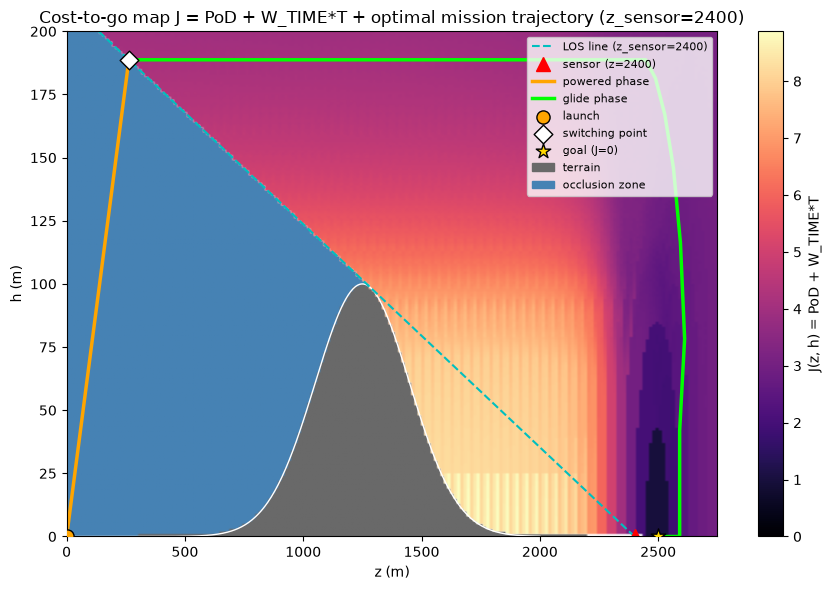

In [21]:
# STEP 6-3 PLOT — Cost-to-Go Map + Optimal Mission Trajectory (z_sensor=2400, load JSON, no recompute)
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np

costmap_2400_path = os.path.join(DATA_DIR, 'costmap_2d_zsensor2400.json')
with open(costmap_2400_path, 'r') as f:
    cm2400 = json.load(f)
step6_2_2400_path = os.path.join(DATA_DIR, 'step6_2_zsensor2400.json')
with open(step6_2_2400_path, 'r') as f:
    s62_2400 = json.load(f)
terrain_path = os.path.join(DATA_DIR, 'terrain.json')
with open(terrain_path, 'r') as f:
    terrain_data = json.load(f)

z_grid_2400 = np.array(cm2400['z_grid'])
h_grid_2400 = np.array(cm2400['h_grid'])
J_2D_2400_plot = np.array(cm2400['J_2D'])
terrain_mask_2d_2400 = np.array(cm2400['terrain_mask_2d'], dtype=bool)
occlusion_mask_2d_2400_plot = np.array(cm2400['occlusion_mask_2d'], dtype=bool)
exclude_mask_2400_plot = np.array(cm2400['exclude_mask_2d'], dtype=bool)
LOS_2400_plot = cm2400['LOS']
sensor_z_2400 = cm2400['params']['Z_SENSOR']
sensor_h_2400 = cm2400['params']['H_SENSOR']

z_terrain = np.array(terrain_data['z_grid'])
h_terrain_vals = np.array(terrain_data['h_terrain'])

z_traj_2400 = np.array(s62_2400['z_traj'])
h_traj_2400 = np.array(s62_2400['h_traj'])
powered_end_2400 = s62_2400['powered_end_index']
z_sw_2400, h_sw_2400 = s62_2400['switching_point']

TERRAIN_COLOR = 'dimgray'
OCCLUSION_COLOR = 'steelblue'
background = np.zeros((len(z_grid_2400), len(h_grid_2400), 4))
background[occlusion_mask_2d_2400_plot] = mcolors.to_rgba(OCCLUSION_COLOR)
background[terrain_mask_2d_2400] = mcolors.to_rgba(TERRAIN_COLOR)

J_plot_2400 = np.where(np.isfinite(J_2D_2400_plot) & ~exclude_mask_2400_plot, J_2D_2400_plot, np.nan)
cmap = plt.get_cmap('magma').copy()
cmap.set_bad(color=(1, 1, 1, 0))
extent = (z_grid_2400[0], z_grid_2400[-1], h_grid_2400[0], h_grid_2400[-1])

plt.figure(figsize=(9, 6))
plt.imshow(np.transpose(background, (1, 0, 2)), origin='lower', extent=extent, aspect='auto')
im = plt.imshow(J_plot_2400.T, origin='lower', extent=extent, aspect='auto', cmap=cmap)
plt.colorbar(im, label='J(z, h) = PoD + W_TIME*T')

plt.plot(z_terrain, h_terrain_vals, 'w-', lw=1.0)
los_line_2400 = LOS_2400_plot['slope'] * z_grid_2400 + LOS_2400_plot['intercept']
plt.plot(z_grid_2400, los_line_2400, 'c--', lw=1.5, label='LOS line (z_sensor=2400)')
plt.plot(sensor_z_2400, sensor_h_2400, 'r^', markersize=10, label='sensor (z=2400)')

plt.plot(z_traj_2400[:powered_end_2400 + 1], h_traj_2400[:powered_end_2400 + 1], color='orange', lw=2.5, label='powered phase')
plt.plot(z_traj_2400[powered_end_2400:], h_traj_2400[powered_end_2400:], color='lime', lw=2.5, label='glide phase')

plt.scatter([params['Z_LAUNCH']], [params['H_LAUNCH']], c='orange', s=90, marker='o', edgecolors='k', zorder=6, label='launch')
plt.scatter([z_sw_2400], [h_sw_2400], c='white', s=90, marker='D', edgecolors='k', zorder=6, label='switching point')
plt.scatter([params['Z_GOAL']], [params['H_GOAL']], c='gold', s=120, marker='*', edgecolors='k', zorder=6, label='goal (J=0)')

legend_handles, legend_labels = plt.gca().get_legend_handles_labels()
legend_handles += [mpatches.Patch(color=TERRAIN_COLOR, label='terrain'),
                    mpatches.Patch(color=OCCLUSION_COLOR, label='occlusion zone')]
plt.legend(handles=legend_handles, loc='upper right', fontsize=8)

plt.xlabel('z (m)')
plt.ylabel('h (m)')
plt.xlim(z_grid_2400[0], z_grid_2400[-1])
plt.ylim(h_grid_2400[0], h_grid_2400[-1])
plt.title('Cost-to-go map J = PoD + W_TIME*T + optimal mission trajectory (z_sensor=2400)')
plt.tight_layout()
plt.show()


## Step 7: Fixed-Wing Glider Model — Simplest Open-Loop Validation

Before reusing `glider_dynamics` (Step 4) inside any optimization pipeline, validate the underlying rigid-body point-mass aerodynamics on their own: same lift/drag/gravity equations of motion, same Cartesian-velocity RK4 integrator, but with **no control input at all** -- the lift coefficient `CL` is held at a single fixed value for the whole simulation instead of being driven by the `required_CL` autopilot.

Initial condition: level flight (`gamma=0`) at altitude `h0` with forward velocity `v0`, with `CL` fixed to exactly the trim value `CL_trim = M*G / (0.5*RHO*v0**2*S)` that balances weight at `v0`. At `t=0` the glider is therefore in exact force balance (`L=W`, no net vertical acceleration); as drag bleeds off speed, lift drops below weight and the glider begins to sink. The expected behavior for a real glider released this way is a **damped phugoid oscillation** (an exchange between kinetic and potential energy at the airframe's natural period) settling toward a steady descending glide. Seeing that shape come out of the simulation (rather than divergence, instant stall, or a straight unphysical line) is the validation signal.


In [22]:
# STEP 7 COMPUTE — Simplest Fixed-Wing Glider: Open-Loop Glide Validation
import math
import numpy as np


def simple_glider_dynamics(state, CL_fixed, dt, params):
    """
    Open-loop fixed-wing glide: CL is held CONSTANT (no autopilot / control
    input at all) -- pure rigid-body point-mass aerodynamics. This isolates
    the lift/drag/gravity equations of motion from any control logic, so we
    can check the bare physics behaves like a real glider (settles into a
    steady descending glide, phugoid oscillation if released away from
    trim) before glider_dynamics' required_CL autopilot is layered on top.
    Same Cartesian-velocity RK4 integration as glider_dynamics (no 1/v
    singularity at low speed). state = (z, h, v, gamma).
    """
    def derivatives(s):
        z, h, vz, vh = s
        v = math.hypot(vz, vh)
        v_safe = max(v, 1e-6)
        CD = drag_coefficient(CL_fixed, params)
        L = 0.5 * params['RHO'] * v**2 * CL_fixed * params['S']
        D = 0.5 * params['RHO'] * v**2 * CD * params['S']
        az = (-D * vz - L * vh) / v_safe / params['M']
        ah = (-D * vh + L * vz) / v_safe / params['M'] - params['G']
        return np.array([vz, vh, az, ah], dtype=float)

    z0, h0, v0, gamma0 = state
    s = np.array([z0, h0, v0 * math.cos(gamma0), v0 * math.sin(gamma0)], dtype=float)

    k1 = derivatives(s)
    k2 = derivatives(s + 0.5 * dt * k1)
    k3 = derivatives(s + 0.5 * dt * k2)
    k4 = derivatives(s + dt * k3)

    s_next = s + dt * (k1 + 2 * k2 + 2 * k3 + k4) / 6.0
    z_next, h_next, vz_next, vh_next = s_next
    h_next = max(h_next, 0.0)
    v_next = math.hypot(vz_next, vh_next)
    gamma_next = math.atan2(vh_next, vz_next)
    return (float(z_next), float(h_next), float(v_next), float(gamma_next))


# --- Initial condition: level flight at altitude h0, forward velocity v0,
# CL fixed exactly at the trim value for v0 (so t=0 is in force balance). ---
h0_test = 100.0
v0_test = float(params['V_LAUNCH'])
CL_trim = params['M'] * params['G'] / (0.5 * params['RHO'] * v0_test**2 * params['S'])
dt_sim = 0.1  # finer than DT_GLIDE so the phugoid (T = pi*sqrt(2)*v0/g =~9.5s at v0=V_LAUNCH) is well resolved
max_t = 60.0

print(f'h0={h0_test}, v0={v0_test:.2f}, CL_trim={CL_trim:.4f} (CL_MAX={params["CL_MAX"]:.4f})')

state = (0.0, h0_test, v0_test, 0.0)
t_list, z_list, h_list, v_list, gamma_list = [0.0], [state[0]], [state[1]], [state[2]], [math.degrees(state[3])]
t = 0.0
while state[1] > 0.0 and t < max_t:
    state = simple_glider_dynamics(state, CL_trim, dt_sim, params)
    t += dt_sim
    t_list.append(t)
    z_list.append(state[0])
    h_list.append(state[1])
    v_list.append(state[2])
    gamma_list.append(math.degrees(state[3]))

print(f'simulated {len(t_list)} steps, t_final={t_list[-1]:.1f}s, h_final={h_list[-1]:.2f}, '
      f'v range=[{min(v_list):.2f}, {max(v_list):.2f}], gamma range=[{min(gamma_list):.2f}, {max(gamma_list):.2f}] deg')

step7_data = {
    'params': params,
    'h0_test': h0_test, 'v0_test': v0_test, 'CL_trim': CL_trim, 'dt_sim': dt_sim,
    't': t_list, 'z': z_list, 'h': h_list, 'v': v_list, 'gamma': gamma_list,
}
step7_path = os.path.join(DATA_DIR, 'step7_simple_glider.json')
with open(step7_path, 'w') as f:
    json.dump(step7_data, f, indent=2)
print('Step 7 data saved to', step7_path)


h0=100.0, v0=21.00, CL_trim=0.5448 (CL_MAX=1.2257)
simulated 601 steps, t_final=60.0s, h_final=42.62, v range=[20.35, 21.53], gamma range=[-4.89, 0.00] deg
Step 7 data saved to D:\git\git_research\glider_hybrid_control\p1b\data\step7_simple_glider.json


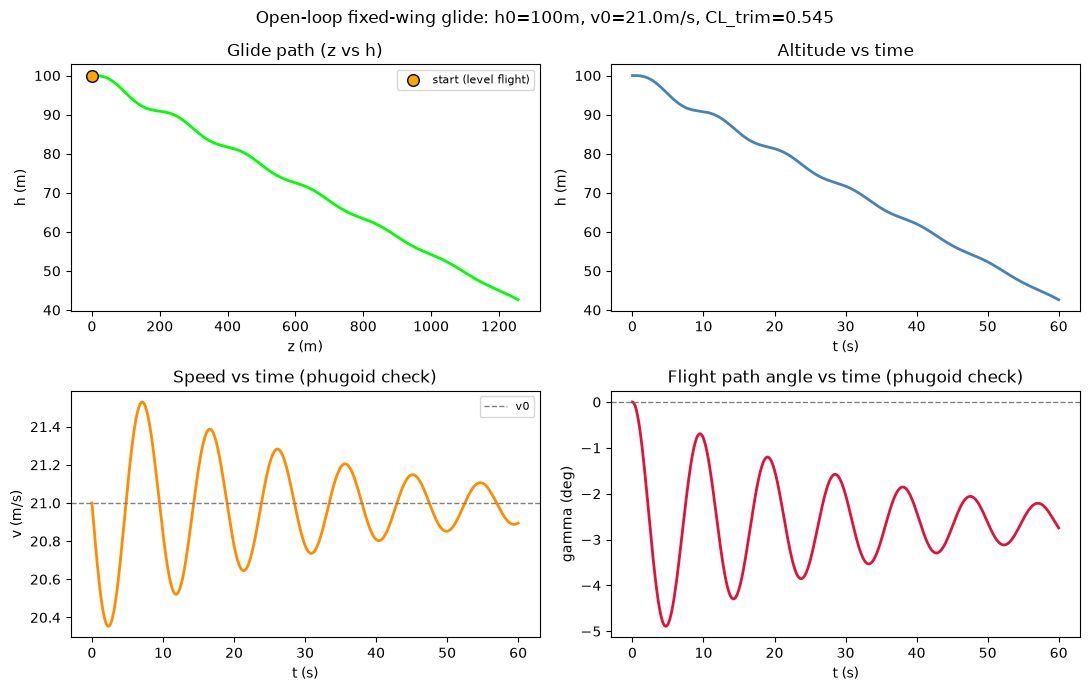

In [23]:
# STEP 7 PLOT — Open-Loop Glide Trajectory + State Histories (load step7_simple_glider.json, no recompute)
import matplotlib.pyplot as plt
import numpy as np

step7_path = os.path.join(DATA_DIR, 'step7_simple_glider.json')
with open(step7_path, 'r') as f:
    s7 = json.load(f)

t7 = np.array(s7['t'])
z7 = np.array(s7['z'])
h7 = np.array(s7['h'])
v7 = np.array(s7['v'])
gamma7 = np.array(s7['gamma'])

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

axes[0, 0].plot(z7, h7, color='lime', lw=2.0)
axes[0, 0].scatter([z7[0]], [h7[0]], c='orange', s=70, marker='o', edgecolors='k', zorder=5, label='start (level flight)')
axes[0, 0].set_xlabel('z (m)')
axes[0, 0].set_ylabel('h (m)')
axes[0, 0].set_title('Glide path (z vs h)')
axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(t7, h7, color='steelblue', lw=2.0)
axes[0, 1].set_xlabel('t (s)')
axes[0, 1].set_ylabel('h (m)')
axes[0, 1].set_title('Altitude vs time')

axes[1, 0].plot(t7, v7, color='darkorange', lw=2.0)
axes[1, 0].axhline(s7['v0_test'], color='gray', ls='--', lw=1.0, label='v0')
axes[1, 0].set_xlabel('t (s)')
axes[1, 0].set_ylabel('v (m/s)')
axes[1, 0].set_title('Speed vs time (phugoid check)')
axes[1, 0].legend(fontsize=8)

axes[1, 1].plot(t7, gamma7, color='crimson', lw=2.0)
axes[1, 1].axhline(0.0, color='gray', ls='--', lw=1.0)
axes[1, 1].set_xlabel('t (s)')
axes[1, 1].set_ylabel('gamma (deg)')
axes[1, 1].set_title('Flight path angle vs time (phugoid check)')

fig.suptitle(f"Open-loop fixed-wing glide: h0={s7['h0_test']:.0f}m, v0={s7['v0_test']:.1f}m/s, "
             f"CL_trim={s7['CL_trim']:.3f}")
plt.tight_layout()
plt.show()


## Step 8: Constant-γ (Closed-Loop) Glide — Does Holding γ Fixed Remove the Phugoid?

Step 7 held `CL` fixed and got a damped phugoid: `v` and `γ` exchange energy as a coupled second-order oscillator because nothing actively corrects the lift/weight mismatch as `v` drifts. This step holds `γ` fixed instead, reusing the existing `glider_dynamics` autopilot (`required_CL`) so `CL` is actively adjusted every substep to keep `γ` at a constant commanded value.

Pinning `γ` removes the oscillatory degree of freedom entirely. What should be left is a first-order relaxation in `v` alone -- it should settle monotonically toward whatever speed balances drag against the gravity-along-path component at that angle, with no oscillation.

Same initial condition as Step 7 (level flight, `h0=100m`, `v0=V_LAUNCH`) for a direct comparison. The commanded `γ` is fixed at `-atan(CD/CL_trim)` -- the steady glide angle Step 7's phugoid was itself slowly converging toward -- so both runs are aimed at the same eventual trim state, just reached differently (oscillating vs. actively flown straight there).


In [24]:
# STEP 8 COMPUTE — Constant-Gamma (Closed-Loop) Glide: holds gamma fixed via the
# existing glider_dynamics autopilot (required_CL), instead of holding CL fixed
# (Step 7). Reuses glider_dynamics/required_CL/drag_coefficient from Step 4.
import math

params_step8 = dict(params)
params_step8['DT_GLIDE'] = 0.1  # match Step 7's fine resolution for direct comparison

h0_test = 100.0
v0_test = float(params['V_LAUNCH'])
CL_trim = params['M'] * params['G'] / (0.5 * params['RHO'] * v0_test**2 * params['S'])
gamma_cmd_fixed = -math.atan(params['CD'] / CL_trim)  # steady glide angle Step 7 converged toward (rad)
max_t = 60.0

print(f'gamma_cmd_fixed = {math.degrees(gamma_cmd_fixed):.3f} deg (held constant via glider_dynamics autopilot)')

state = (0.0, h0_test, v0_test, 0.0)  # SAME initial condition as Step 7: level flight, v0, h0
t_list, z_list, h_list, v_list, gamma_list = [0.0], [state[0]], [state[1]], [state[2]], [math.degrees(state[3])]
t = 0.0
while state[1] > 0.0 and t < max_t:
    state = glider_dynamics(state, gamma_cmd_fixed, params_step8)
    t += params_step8['DT_GLIDE']
    t_list.append(t)
    z_list.append(state[0])
    h_list.append(state[1])
    v_list.append(state[2])
    gamma_list.append(math.degrees(state[3]))

print(f'simulated {len(t_list)} steps, t_final={t_list[-1]:.1f}s, h_final={h_list[-1]:.2f}, '
      f'v range=[{min(v_list):.2f}, {max(v_list):.2f}], gamma range=[{min(gamma_list):.2f}, {max(gamma_list):.2f}] deg')

step8_data = {
    'params': params_step8,
    'h0_test': h0_test, 'v0_test': v0_test, 'gamma_cmd_fixed_deg': math.degrees(gamma_cmd_fixed),
    't': t_list, 'z': z_list, 'h': h_list, 'v': v_list, 'gamma': gamma_list,
}
step8_path = os.path.join(DATA_DIR, 'step8_constant_gamma.json')
with open(step8_path, 'w') as f:
    json.dump(step8_data, f, indent=2)
print('Step 8 data saved to', step8_path)


gamma_cmd_fixed = -2.627 deg (held constant via glider_dynamics autopilot)
simulated 601 steps, t_final=60.0s, h_final=43.66, v range=[20.61, 21.00], gamma range=[-2.63, 0.00] deg
Step 8 data saved to D:\git\git_research\glider_hybrid_control\p1b\data\step8_constant_gamma.json


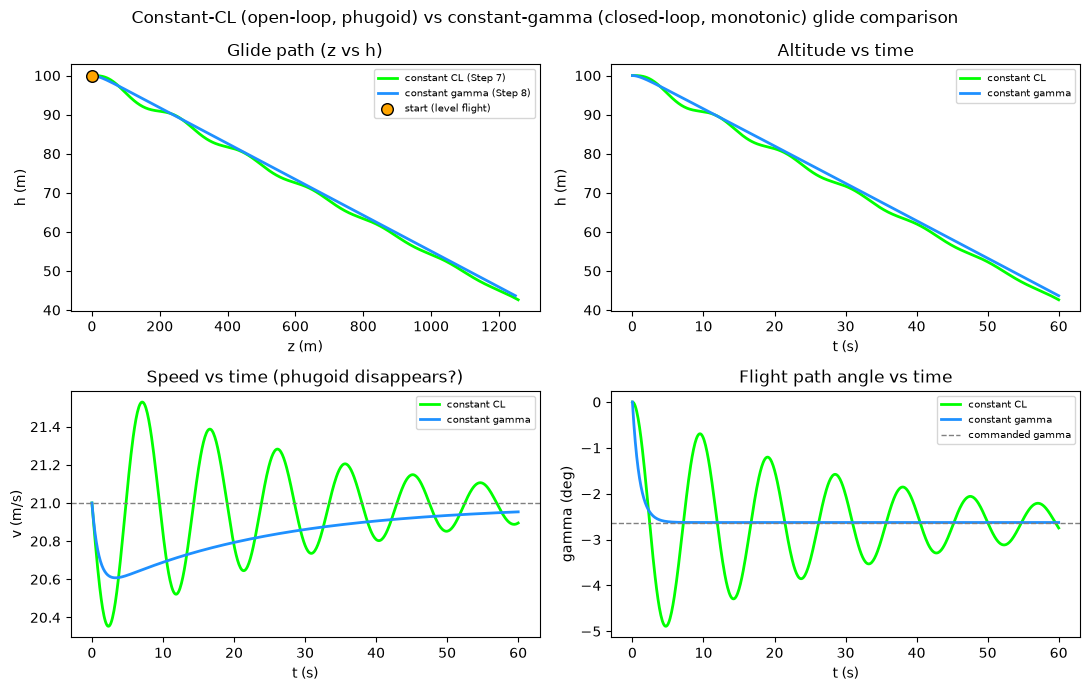

In [25]:
# STEP 8 PLOT — Constant-Gamma vs Constant-CL Comparison (load step7_simple_glider.json + step8_constant_gamma.json, no recompute)
import matplotlib.pyplot as plt
import numpy as np

step7_path = os.path.join(DATA_DIR, 'step7_simple_glider.json')
with open(step7_path, 'r') as f:
    s7 = json.load(f)
step8_path = os.path.join(DATA_DIR, 'step8_constant_gamma.json')
with open(step8_path, 'r') as f:
    s8 = json.load(f)

t7, z7, h7, v7, g7 = (np.array(s7[k]) for k in ('t', 'z', 'h', 'v', 'gamma'))
t8, z8, h8, v8, g8 = (np.array(s8[k]) for k in ('t', 'z', 'h', 'v', 'gamma'))

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

axes[0, 0].plot(z7, h7, color='lime', lw=2.0, label='constant CL (Step 7)')
axes[0, 0].plot(z8, h8, color='dodgerblue', lw=2.0, label='constant gamma (Step 8)')
axes[0, 0].scatter([0.0], [s7['h0_test']], c='orange', s=70, marker='o', edgecolors='k', zorder=5, label='start (level flight)')
axes[0, 0].set_xlabel('z (m)')
axes[0, 0].set_ylabel('h (m)')
axes[0, 0].set_title('Glide path (z vs h)')
axes[0, 0].legend(fontsize=7)

axes[0, 1].plot(t7, h7, color='lime', lw=2.0, label='constant CL')
axes[0, 1].plot(t8, h8, color='dodgerblue', lw=2.0, label='constant gamma')
axes[0, 1].set_xlabel('t (s)')
axes[0, 1].set_ylabel('h (m)')
axes[0, 1].set_title('Altitude vs time')
axes[0, 1].legend(fontsize=7)

axes[1, 0].plot(t7, v7, color='lime', lw=2.0, label='constant CL')
axes[1, 0].plot(t8, v8, color='dodgerblue', lw=2.0, label='constant gamma')
axes[1, 0].axhline(s7['v0_test'], color='gray', ls='--', lw=1.0)
axes[1, 0].set_xlabel('t (s)')
axes[1, 0].set_ylabel('v (m/s)')
axes[1, 0].set_title('Speed vs time (phugoid disappears?)')
axes[1, 0].legend(fontsize=7)

axes[1, 1].plot(t7, g7, color='lime', lw=2.0, label='constant CL')
axes[1, 1].plot(t8, g8, color='dodgerblue', lw=2.0, label='constant gamma')
axes[1, 1].axhline(s8['gamma_cmd_fixed_deg'], color='gray', ls='--', lw=1.0, label='commanded gamma')
axes[1, 1].set_xlabel('t (s)')
axes[1, 1].set_ylabel('gamma (deg)')
axes[1, 1].set_title('Flight path angle vs time')
axes[1, 1].legend(fontsize=7)

fig.suptitle('Constant-CL (open-loop, phugoid) vs constant-gamma (closed-loop, monotonic) glide comparison')
plt.tight_layout()
plt.show()


## Step 9: 4D Backward DP Cost-to-Go Map (Fixed-Wing)

Loads `p1b_4d_dp_results.npz` (produced offline by `p1b_4d_dp.py`, which runs
the exact `(z,h,v,γ)` backward DP for the fixed-wing model -- unlike the 2D
point-mass baseline where `(v,γ)` reset freely each stage, the fixed-wing
model carries velocity and flight-path angle as real physical state between
stages).

**Domain fix**: the glide-phase DP now propagates cost-to-go **only within
the LOS-visible zone**, exactly like the point-mass baseline's `exclude_mask`
(Step 6-1). The occlusion pocket behind the ridge is the powered phase's
territory (straight-line launch `(0,0)` → switching point on the LOS
boundary), not the glide-phase cost-to-go map's -- letting cost-to-go leak
into that pocket would have the glide DP silently re-solving territory that
already belongs to (and is handled differently by) the powered phase. The
plot below confirms this: both panels should show the same excluded
(blank/white) occlusion pocket below the LOS line.

This section only loads and visualizes the map to confirm the domain fix.
**Trajectory execution is deferred** -- the DP's own internal forward
simulation still starts mid-air at a hardcoded `(z=0, h=250m)`, which is now
(correctly) outside the glide-phase domain and immediately fails. A real 4D
mission trajectory needs the same **powered phase + switching-point**
structure as Step 6-2 (launch → optimized switching point on the LOS
boundary → glide phase governed by this cost-to-go map), which hasn't been
rebuilt yet for the 4D state.


In [26]:
# STEP 9 COMPUTE -- Load 4D DP results (no recompute: reads
# p1b_4d_dp_results.npz cached by p1b_4d_dp.py, which now restricts the
# glide-phase DP domain to the LOS-visible zone only via exclude_mask_2d)
import numpy as np

res4d = np.load(os.path.join(DATA_DIR, 'p1b_4d_dp_results.npz'))
J_4D       = res4d['J_4D']         # (NZ4, NH4, NV, NG)
policy_4D  = res4d['policy_4D']
z_grid_4d  = res4d['z_grid']
h_grid_4d  = res4d['h_grid']
v_grid_4d  = res4d['v_grid']
g_grid_4d  = res4d['gamma_grid']   # degrees
a_grid_4d  = res4d['gamma_cmd_grid']  # degrees
NZ4, NH4, NV4, NG4 = J_4D.shape

# J_2D_4d = min over (v, gamma) of J_4D -- best-case cost at each (z,h)
J_2D_4d = np.nanmin(np.where(np.isfinite(J_4D.reshape(NZ4, NH4, -1)),
                              J_4D.reshape(NZ4, NH4, -1), np.nan), axis=-1)
fin_4d = np.isfinite(J_2D_4d)
print(f'J_2D_4d: finite={fin_4d.sum()}/{NZ4*NH4}  range=[{J_2D_4d[fin_4d].min():.4f}, {J_2D_4d[fin_4d].max():.4f}]')


J_2D_4d: finite=5725/10000  range=[0.0000, 2.8468]


C:\Users\jeffe\AppData\Local\Temp\ipykernel_11508\2377981948.py:17: RuntimeWarning: All-NaN slice encountered
  J_2D_4d = np.nanmin(np.where(np.isfinite(J_4D.reshape(NZ4, NH4, -1)),


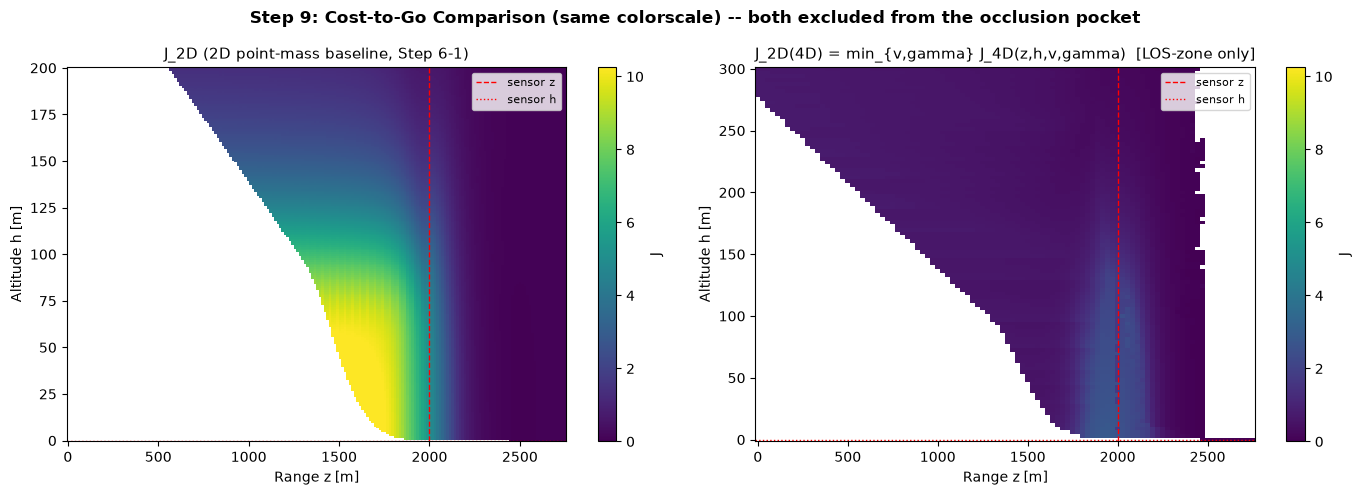

step9_plot1_J_comparison.png saved
  2D baseline: 22366 finite cells, J range [0.0000, 10.7444]
  4D projected: 5725 finite cells, J range [0.0000, 2.8468]


In [27]:
# STEP 9 PLOT 1 -- J_2D_4d vs J_2D baseline side-by-side heatmap
# J_2D and z_grid, h_grid are defined in Step 6-1's compute cell (2D
# point-mass baseline). Both panels should show the same excluded
# (blank/white) occlusion pocket below the LOS line -- that's the domain
# fix being confirmed here.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

Jb = np.where(np.isfinite(J_2D), J_2D, np.nan)
J4 = np.where(np.isfinite(J_2D_4d), J_2D_4d, np.nan)
vmax_common = np.nanpercentile(np.concatenate([Jb.ravel()[np.isfinite(Jb.ravel())],
                                               J4.ravel()[np.isfinite(J4.ravel())]]), 98)

ax0 = axes[0]
im0 = ax0.pcolormesh(z_grid, h_grid, Jb.T, cmap='viridis', vmin=0, vmax=vmax_common)
fig.colorbar(im0, ax=ax0, label='J')
ax0.set_title('J_2D (2D point-mass baseline, Step 6-1)', fontsize=11)
ax0.set_xlabel('Range z [m]'); ax0.set_ylabel('Altitude h [m]')
ax0.axvline(params['Z_SENSOR'], color='red', lw=1, ls='--', label='sensor z')
ax0.axhline(params['H_SENSOR'], color='red', lw=1, ls=':', label='sensor h')
ax0.legend(fontsize=8)

ax1 = axes[1]
im1 = ax1.pcolormesh(z_grid_4d, h_grid_4d, J4.T, cmap='viridis', vmin=0, vmax=vmax_common)
fig.colorbar(im1, ax=ax1, label='J')
ax1.set_title('J_2D(4D) = min_{v,gamma} J_4D(z,h,v,gamma)  [LOS-zone only]', fontsize=11)
ax1.set_xlabel('Range z [m]'); ax1.set_ylabel('Altitude h [m]')
ax1.axvline(params['Z_SENSOR'], color='red', lw=1, ls='--', label='sensor z')
ax1.axhline(params['H_SENSOR'], color='red', lw=1, ls=':', label='sensor h')
ax1.legend(fontsize=8)

plt.suptitle('Step 9: Cost-to-Go Comparison (same colorscale) -- both excluded from the occlusion pocket', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'step9_plot1_J_comparison.png'), dpi=120, bbox_inches='tight')
plt.show()
fin2d = np.sum(np.isfinite(Jb))
fin4d = np.sum(np.isfinite(J4))
print(f'step9_plot1_J_comparison.png saved')
print(f'  2D baseline: {fin2d} finite cells, J range [{np.nanmin(Jb):.4f}, {np.nanmax(Jb):.4f}]')
print(f'  4D projected: {fin4d} finite cells, J range [{np.nanmin(J4):.4f}, {np.nanmax(J4):.4f}]')


C:\Users\jeffe\AppData\Local\Temp\ipykernel_11508\2248001757.py:13: RuntimeWarning: All-NaN slice encountered
  Jslice = np.nanmin(J4slice_all[:, :, iv, :], axis=-1)   # (NZ4, NH4)


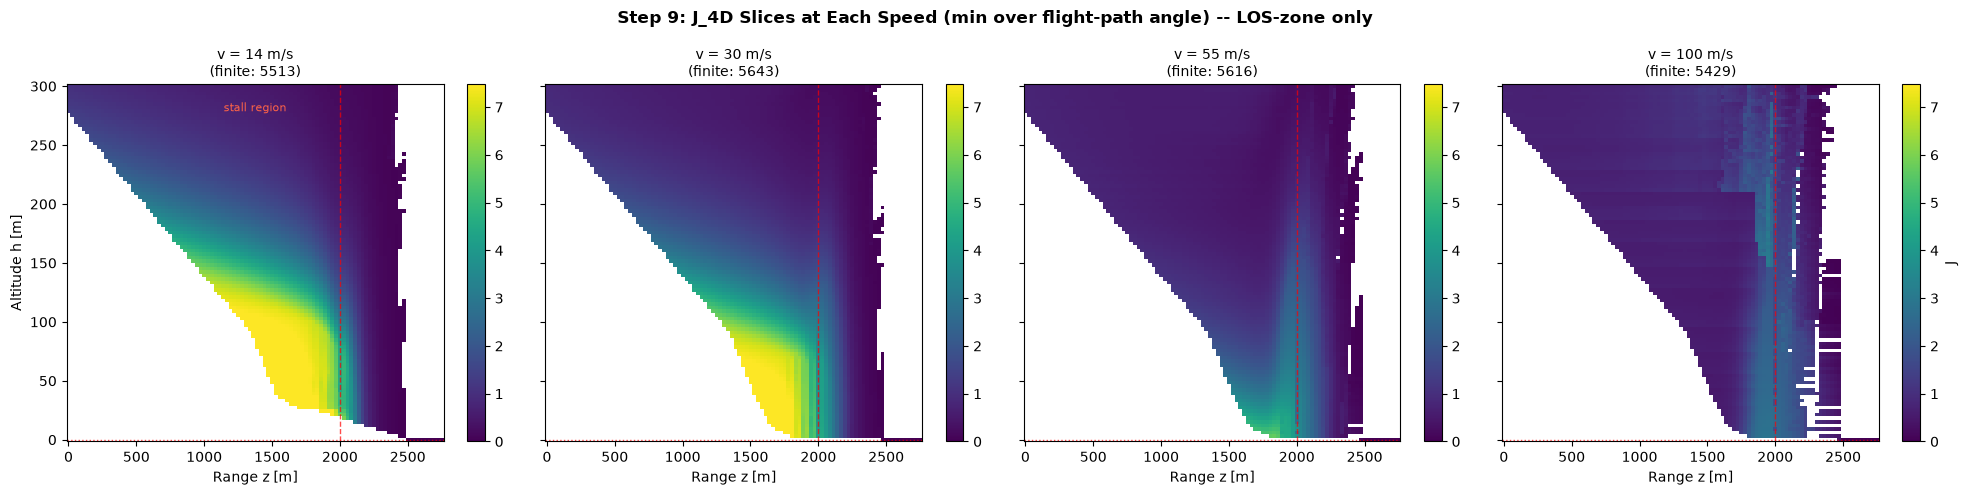

step9_plot2_J4D_slices.png saved


In [28]:
# STEP 9 PLOT 2 -- J_4D slices at each v, minimized over gamma
# Confirms the LOS-zone-only domain fix holds at every speed, not just in
# the v-minimized projection above.
fig, axes = plt.subplots(1, NV4, figsize=(5 * NV4, 5), sharey=True)
if NV4 == 1:
    axes = [axes]

J4slice_all = np.where(np.isfinite(J_4D), J_4D, np.nan)
vmax_slice = np.nanpercentile(J4slice_all.ravel()[np.isfinite(J4slice_all.ravel())], 97)

for iv, vv in enumerate(v_grid_4d):
    ax = axes[iv]
    Jslice = np.nanmin(J4slice_all[:, :, iv, :], axis=-1)   # (NZ4, NH4)
    im = ax.pcolormesh(z_grid_4d, h_grid_4d, Jslice.T,
                       cmap='viridis', vmin=0, vmax=vmax_slice)
    fig.colorbar(im, ax=ax, label='J' if iv == NV4-1 else '')
    ax.set_title(f'v = {vv:.0f} m/s\n(finite: {np.sum(np.isfinite(Jslice))})', fontsize=10)
    ax.set_xlabel('Range z [m]')
    if iv == 0:
        ax.set_ylabel('Altitude h [m]')
    ax.axvline(params['Z_SENSOR'], color='red', lw=1, ls='--', alpha=0.7)
    ax.axhline(params['H_SENSOR'], color='red', lw=1, ls=':', alpha=0.7)
    if vv <= params['V_STALL'] + 1:
        ax.text(0.5, 0.95, 'stall region', transform=ax.transAxes,
                ha='center', va='top', fontsize=8, color='tomato')

plt.suptitle('Step 9: J_4D Slices at Each Speed (min over flight-path angle) -- LOS-zone only',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'step9_plot2_J4D_slices.png'), dpi=120, bbox_inches='tight')
plt.show()
print('step9_plot2_J4D_slices.png saved')


### Step 9-2: Switching-Point Search + Full Mission Trajectory (Powered + Glide)

Mirrors Step 6-2's structure for the fixed-wing 4D case: reuses the same
LOS-line switching candidates (Step 2 / `terrain.json`) and the same
straight-line `powered_trajectory` kinematics, but evaluates each candidate
by interpolating `J_4D` at its actual entry state `(z_sw, h_sw, V_LAUNCH,
γ=atan2(h_sw,z_sw))` instead of a 2D `(z,h)`-only lookup -- the entry `γ` is
often a real climb angle (up to ~90° for candidates near launch), which is
why the state grid (`g_grid`) was extended to `[-90°, 90°]` while the action
grid (`gamma_cmd`) stayed glide-only `[-90°, 0°]` (see `p1b_4d_dp.py`).

The switching-candidate lookup uses the same reach-weighted interpolation
trick as the DP's own backward sweep (`J_reach`/`J_val` conditional mean) --
candidates sit exactly on the LOS boundary, so a naive interpolator blends
finite (visible) and `inf` (occluded) grid corners and makes every candidate
look unreachable.

**Known issue**: the best candidate found lands ~7m short of `Z_GOAL` (a
steep terminal dive eats into forward progress right at the end) -- flagged
as a near-miss, not swept under the rug. Shown below for inspection.


In [29]:
# STEP 9-2 COMPUTE -- Load switching-point search + full trajectory
# (no recompute: reads trajectory_4d.json cached by p1b_4d_dp.py)
with open(os.path.join(DATA_DIR, 'trajectory_4d.json'), 'r') as f:
    traj4d = json.load(f)

cand4d = traj4d['candidates']
n_reach4d = sum(c['reachable'] for c in cand4d)
print(f'{n_reach4d} / {len(cand4d)} switching candidates reachable (fixed-wing 4D)')
z_sw4, h_sw4 = traj4d['switching_point']
print(f"optimal switching point: (z={z_sw4:.1f}, h={h_sw4:.1f})")

pow_end4 = traj4d['powered_end_index']
t4, z4, h4, v4, g4 = (np.array(traj4d[k]) for k in ('t_traj', 'z_traj', 'h_traj', 'v_traj', 'gamma_traj'))
pod4, J4c = np.array(traj4d['pod_traj']), np.array(traj4d['cost_traj'])
print(f"final PoD={traj4d['final_pod']:.4f}, T={traj4d['T_total']:.1f}s, J={traj4d['J_total']:.4f}")
print(f"landed at z={z4[-1]:.1f} (Z_GOAL={params['Z_GOAL']:.1f}, short by {params['Z_GOAL']-z4[-1]:.1f}m)"
      if z4[-1] < params['Z_GOAL'] else f"landed at z={z4[-1]:.1f} -- reached goal")


6 / 20 switching candidates reachable (fixed-wing 4D)
optimal switching point: (z=460.5, h=213.3)
final PoD=0.9733, T=123.0s, J=1.0963
landed at z=2492.6 (Z_GOAL=2500.0, short by 7.4m)


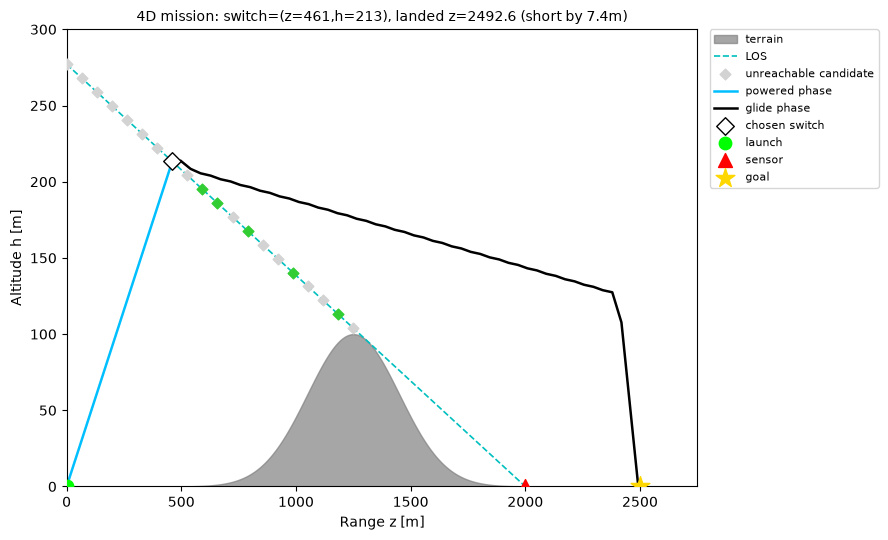

step9_plot3a_trajectory_zh.png saved


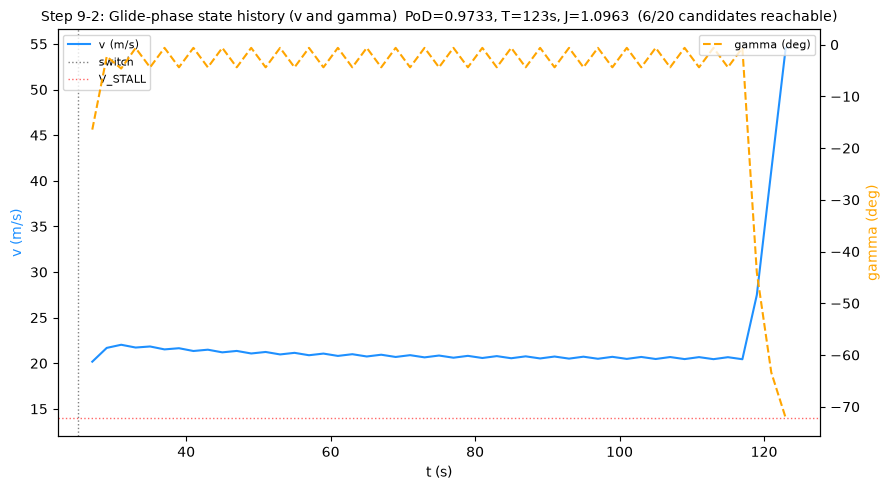

step9_plot3b_state_history.png saved


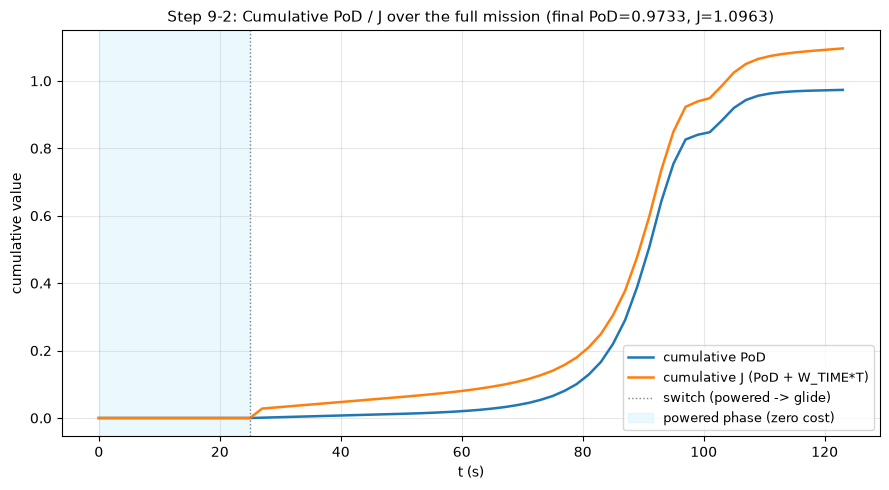

step9_plot3c_cumulative.png saved


In [30]:
# STEP 9-2 PLOT -- Switching candidates + full mission trajectory (powered + glide)
# Local terrain/LOS curves for plotting (self-contained -- don't rely on
# whichever earlier cell happened to leave zt/ht/h_los_line set)
zt9 = np.linspace(0, z_grid_4d[-1], 400)
ht9 = h_terrain(zt9, params)
h_los_line9 = LOS['slope'] * zt9 + LOS['intercept']

# --- Figure 1: trajectory in the z-h plane (own figure, legend outside) ---
fig0, ax0 = plt.subplots(figsize=(9, 5.5))
ax0.fill_between(zt9, 0, ht9, color='gray', alpha=0.7, label='terrain')
ax0.plot(zt9, h_los_line9, 'c--', lw=1.2, label='LOS')

for c in cand4d:
    is_best = (abs(c['z_sw'] - z_sw4) < 1e-6 and abs(c['h_sw'] - h_sw4) < 1e-6)
    if is_best:
        continue
    color = 'limegreen' if c['reachable'] else 'lightgray'
    ax0.scatter([c['z_sw']], [c['h_sw']], c=color, marker='D', s=30, zorder=4,
                label=('reachable candidate' if c['reachable'] else 'unreachable candidate')
                if c is cand4d[0] else None)

ax0.plot(z4[:pow_end4+1], h4[:pow_end4+1], color='deepskyblue', lw=1.8, label='powered phase')
ax0.plot(z4[pow_end4+1:], h4[pow_end4+1:], color='black', lw=1.8, label='glide phase')
ax0.scatter([z_sw4], [h_sw4], c='white', edgecolor='black', marker='D', s=80, zorder=6, label='chosen switch')
ax0.scatter([0.0], [0.0], c='lime', marker='o', s=80, zorder=6, label='launch')
ax0.scatter([params['Z_SENSOR']], [params['H_SENSOR']], c='red', marker='^', s=100, zorder=6, label='sensor')
ax0.scatter([params['Z_GOAL']], [params['H_GOAL']], c='gold', marker='*', s=200, zorder=6, label='goal')
ax0.set_xlim(0, z_grid_4d[-1]); ax0.set_ylim(0, h_grid_4d[-1])
ax0.set_xlabel('Range z [m]'); ax0.set_ylabel('Altitude h [m]')
ax0.set_title(f'4D mission: switch=(z={z_sw4:.0f},h={h_sw4:.0f}), landed z={z4[-1]:.1f}'
              + (f' (short by {params["Z_GOAL"]-z4[-1]:.1f}m)' if z4[-1] < params['Z_GOAL'] else ' (reached goal)'),
              fontsize=10)
ax0.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'step9_plot3a_trajectory_zh.png'), dpi=120, bbox_inches='tight')
plt.show()
print('step9_plot3a_trajectory_zh.png saved')

# --- Figure 2: glide-phase state history (v, gamma) vs time (own figure) ---
fig1, ax1 = plt.subplots(figsize=(9, 5))
t_glide = t4[pow_end4+1:]
ax1.plot(t_glide, v4[pow_end4+1:], color='dodgerblue', label='v (m/s)')
ax1b = ax1.twinx()
ax1b.plot(t_glide, g4[pow_end4+1:], color='orange', ls='--', label='gamma (deg)')
ax1b.set_ylabel('gamma (deg)', color='orange')
ax1.axvline(t4[pow_end4], color='gray', ls=':', lw=1, label='switch')
ax1.axhline(params['V_STALL'], color='red', ls=':', lw=1, alpha=0.6, label='V_STALL')
ax1.set_xlabel('t (s)'); ax1.set_ylabel('v (m/s)', color='dodgerblue')
ax1.set_title(f"Step 9-2: Glide-phase state history (v and gamma)  "
              f"PoD={traj4d['final_pod']:.4f}, T={traj4d['T_total']:.0f}s, J={traj4d['J_total']:.4f}  "
              f"({n_reach4d}/{len(cand4d)} candidates reachable)", fontsize=10)
ax1.legend(loc='upper left', fontsize=8); ax1b.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'step9_plot3b_state_history.png'), dpi=120, bbox_inches='tight')
plt.show()
print('step9_plot3b_state_history.png saved')

# --- Figure 3: cumulative PoD / J vs time (full mission, powered+glide) ---
fig2, ax2 = plt.subplots(figsize=(9, 5))
ax2.plot(t4, pod4, color='C0', lw=1.8, label='cumulative PoD')
ax2.plot(t4, J4c, color='C1', lw=1.8, label='cumulative J (PoD + W_TIME*T)')
ax2.axvline(t4[pow_end4], color='gray', ls=':', lw=1, label='switch (powered -> glide)')
ax2.axvspan(0, t4[pow_end4], color='deepskyblue', alpha=0.08, label='powered phase (zero cost)')
ax2.set_xlabel('t (s)'); ax2.set_ylabel('cumulative value')
ax2.set_title(f"Step 9-2: Cumulative PoD / J over the full mission "
              f"(final PoD={traj4d['final_pod']:.4f}, J={traj4d['J_total']:.4f})", fontsize=11)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'step9_plot3c_cumulative.png'), dpi=120, bbox_inches='tight')
plt.show()
print('step9_plot3c_cumulative.png saved')


### Step 9-4: 2D (Point-Mass) vs 4D (Fixed-Wing) Trajectory Comparison

Overlays both full missions (powered + glide) on the same `(z,h)` plane, on
top of the 2D point-mass baseline's cost-to-go heatmap (`J_2D`, Step 6-1) so
the 4D trajectory can be sanity-checked against the already-established
baseline landscape. Terrain, LOS line, all 20 switching candidates, both
models' chosen switching points, sensor, goal, and launch are all marked.


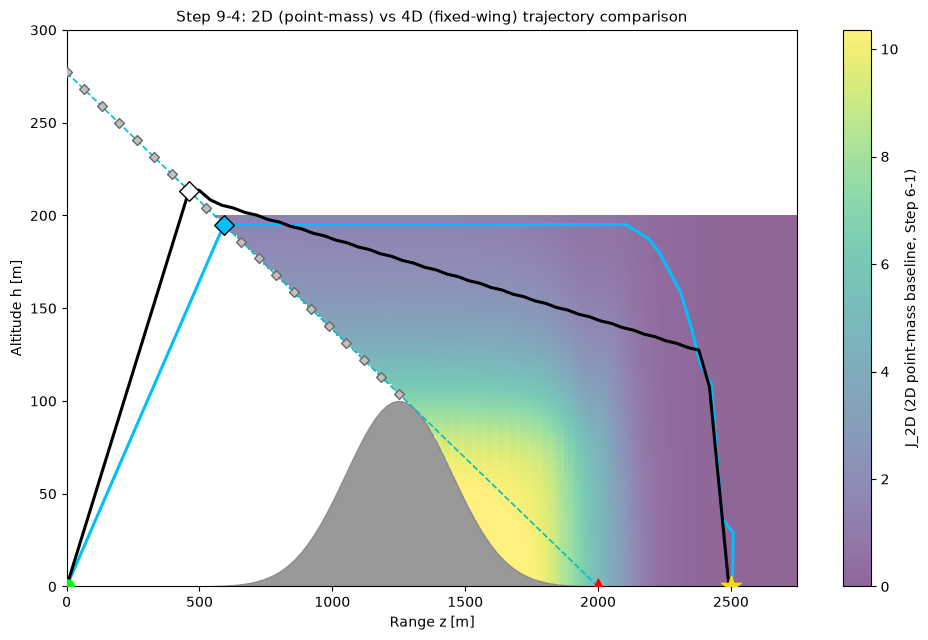

step9_4_2d_vs_4d.png saved
2D switch: (z=592.1, h=195.1)   4D switch: (z=460.5, h=213.3)
2D landed: z=2505.0, h=0.0   4D landed: z=2492.6, h=0.0


In [31]:
# STEP 9-4 PLOT -- 2D vs 4D trajectory comparison (load step6_2.json fresh,
# reuse traj4d from Step 9-2, no recompute)
with open(os.path.join(DATA_DIR, 'step6_2.json'), 'r') as f:
    s62_94 = json.load(f)
z2d_94, h2d_94 = np.array(s62_94['z_traj']), np.array(s62_94['h_traj'])
z_sw2d_94, h_sw2d_94 = s62_94['switching_point']

with open(os.path.join(DATA_DIR, 'terrain.json'), 'r') as f:
    terrain_94 = json.load(f)
switching_candidates_94 = terrain_94['switching_candidates']

zmax_94 = max(z_grid[-1], z_grid_4d[-1])
hmax_94 = max(h_grid[-1], h_grid_4d[-1])
zt94 = np.linspace(0, zmax_94, 400)
ht94 = h_terrain(zt94, params)
h_los_94 = LOS['slope'] * zt94 + LOS['intercept']

fig, ax = plt.subplots(figsize=(10, 6.5))

# 2D projected cost-to-go heatmap (point-mass baseline, Step 6-1) as background
Jb94 = np.where(np.isfinite(J_2D), J_2D, np.nan)
im = ax.pcolormesh(z_grid, h_grid, Jb94.T, cmap='viridis', alpha=0.6, vmin=0,
                    vmax=np.nanpercentile(Jb94[np.isfinite(Jb94)], 98), shading='auto')
fig.colorbar(im, ax=ax, label='J_2D (2D point-mass baseline, Step 6-1)')

ax.fill_between(zt94, 0, ht94, color='gray', alpha=0.8, label='terrain')
ax.plot(zt94, h_los_94, 'c--', lw=1.2, label='LOS')

for i, (zc, hc) in enumerate(switching_candidates_94):
    ax.scatter([zc], [hc], c='silver', edgecolor='dimgray', marker='D', s=25, zorder=3,
               label='switching candidate' if i == 0 else None)

ax.plot(z2d_94, h2d_94, color='deepskyblue', lw=2.2, label='2D point-mass trajectory (Step 6-2)')
ax.plot(z4, h4, color='black', lw=2.2, label='4D fixed-wing trajectory (Step 9-2)')

ax.scatter([z_sw2d_94], [h_sw2d_94], marker='D', s=100, facecolor='deepskyblue', edgecolor='black',
           zorder=6, label='2D switch point')
ax.scatter([z_sw4], [h_sw4], marker='D', s=100, facecolor='white', edgecolor='black',
           zorder=6, label='4D switch point')

ax.scatter([0.0], [0.0], c='lime', marker='o', s=90, zorder=6, label='start (launch)')
ax.scatter([params['Z_SENSOR']], [params['H_SENSOR']], c='red', marker='^', s=110, zorder=6, label='sensor')
ax.scatter([params['Z_GOAL']], [params['H_GOAL']], c='gold', marker='*', s=220, zorder=6, label='goal')

ax.set_xlim(0, zmax_94); ax.set_ylim(0, hmax_94)
ax.set_xlabel('Range z [m]'); ax.set_ylabel('Altitude h [m]')
ax.set_title('Step 9-4: 2D (point-mass) vs 4D (fixed-wing) trajectory comparison', fontsize=11)
# ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.28, 1.0), borderaxespad=0)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'step9_4_2d_vs_4d.png'), dpi=120, bbox_inches='tight')
plt.show()
print('step9_4_2d_vs_4d.png saved')
print(f"2D switch: (z={z_sw2d_94:.1f}, h={h_sw2d_94:.1f})   4D switch: (z={z_sw4:.1f}, h={h_sw4:.1f})")
print(f"2D landed: z={z2d_94[-1]:.1f}, h={h2d_94[-1]:.1f}   4D landed: z={z4[-1]:.1f}, h={h4[-1]:.1f}")


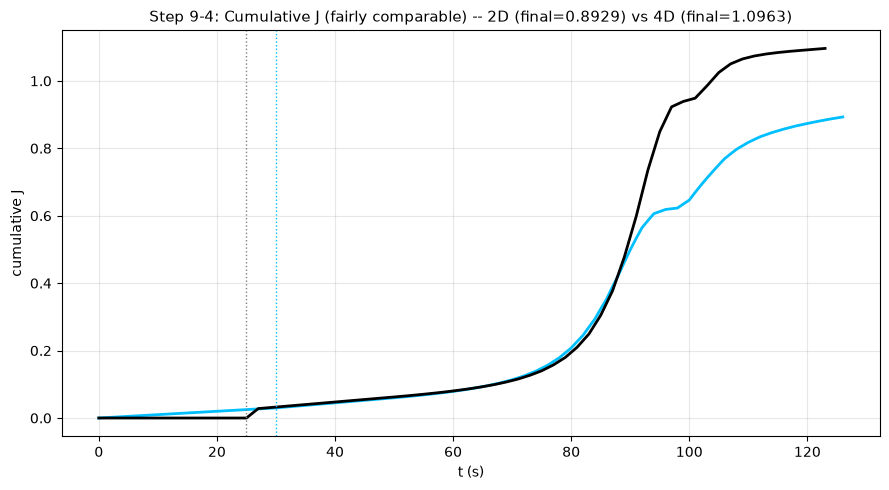

step9_4b_cumJ.png saved
2D: final PoD=0.7669, J=0.8929, T=126.0s
4D: final PoD=0.9733, J=1.0963, T=123.0s
(for reference, step6_2.json's own routing-cost cost_traj[-1] = 1.5015 -- NOT comparable, different accumulation)


In [32]:
# STEP 9-4b PLOT -- Cumulative J: 2D point-mass vs 4D fixed-wing
t2d_94 = np.array(s62_94['t_traj'])
pod2d_94 = np.array(s62_94['pod_traj'])
v2d_94 = np.array(s62_94['v_traj'])
g2d_94 = np.array(s62_94['gamma_traj'])

# NOTE: step6_2.json's own 'cost_traj' is NOT PoD+W_TIME*T -- it's the raw
# Dijkstra routing cost (a linear sum of per-stage PoDs, deliberately left
# unfixed earlier since it's the *optimization objective*, not a reported
# metric -- see the PoD-accumulation-bug fix in Step 6-2). It is therefore
# NOT comparable to J4c (4D's J, which IS PoD+W_TIME*T). Recompute a fairly
# comparable J for 2D from its already-correct (hazard-based) pod_traj:
J2d_94 = pod2d_94 + params['W_TIME'] * t2d_94

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t2d_94, J2d_94, color='deepskyblue', lw=2, label='2D point-mass (cumulative J = PoD + W_TIME*T)')
ax.plot(t4, J4c, color='black', lw=2, label='4D fixed-wing (cumulative J = PoD + W_TIME*T)')
ax.axvline(t2d_94[s62_94['powered_end_index']], color='deepskyblue', ls=':', lw=1)
ax.axvline(t4[pow_end4], color='gray', ls=':', lw=1)
ax.set_xlabel('t (s)'); ax.set_ylabel('cumulative J')
ax.set_title(f"Step 9-4: Cumulative J (fairly comparable) -- 2D (final={J2d_94[-1]:.4f}) vs 4D (final={J4c[-1]:.4f})",
             fontsize=11)
# ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'step9_4b_cumJ.png'), dpi=120, bbox_inches='tight')
plt.show()
print('step9_4b_cumJ.png saved')
print(f"2D: final PoD={pod2d_94[-1]:.4f}, J={J2d_94[-1]:.4f}, T={t2d_94[-1]:.1f}s")
print(f"4D: final PoD={traj4d['final_pod']:.4f}, J={J4c[-1]:.4f}, T={t4[-1]:.1f}s")
print(f"(for reference, step6_2.json's own routing-cost cost_traj[-1] = {s62_94['cost_traj'][-1]:.4f} -- NOT comparable, different accumulation)")


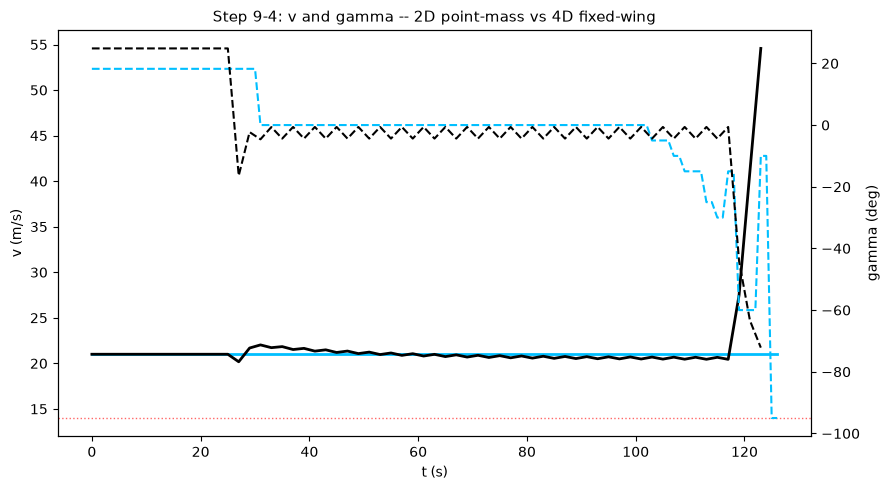

step9_4c_vgamma.png saved


In [33]:
# STEP 9-4c PLOT -- v and gamma: 2D point-mass (constant v, by construction) vs 4D fixed-wing
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t2d_94, v2d_94, color='deepskyblue', lw=2, label='v 2D (m/s)')
ax.plot(t4, v4, color='black', lw=2, label='v 4D (m/s)')
axb = ax.twinx()
axb.plot(t2d_94, g2d_94, color='deepskyblue', ls='--', lw=1.5, label='gamma 2D (deg)')
axb.plot(t4, g4, color='black', ls='--', lw=1.5, label='gamma 4D (deg)')
axb.set_ylabel('gamma (deg)')
ax.axhline(params['V_STALL'], color='red', ls=':', lw=1, alpha=0.6, label='V_STALL')
ax.set_xlabel('t (s)'); ax.set_ylabel('v (m/s)')
ax.set_title('Step 9-4: v and gamma -- 2D point-mass vs 4D fixed-wing', fontsize=11)
# ax.legend(loc='upper left', fontsize=8)
# axb.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'step9_4c_vgamma.png'), dpi=120, bbox_inches='tight')
plt.show()
print('step9_4c_vgamma.png saved')


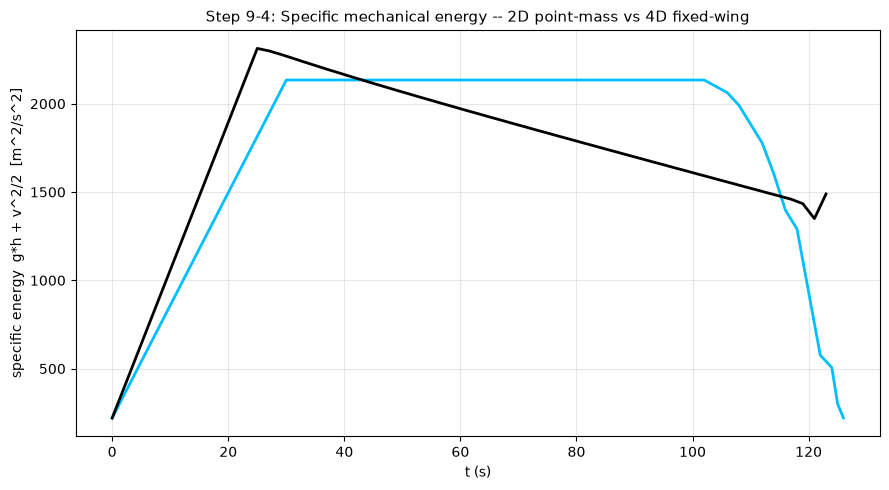

step9_4d_energy.png saved
2D energy: start=220.5, end=220.5, delta=0.0
4D energy: start=220.5, end=1489.1, delta=1268.6


In [34]:
# STEP 9-4d PLOT -- Specific mechanical energy: 2D point-mass vs 4D fixed-wing
# e = (KE + PE) / m = g*h + (1/2)*v^2  [m^2/s^2 = J/kg]
e2d_94 = params['G'] * h2d_94 + 0.5 * v2d_94**2
e4d_94 = params['G'] * h4 + 0.5 * v4**2

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t2d_94, e2d_94, color='deepskyblue', lw=2, label='2D specific energy')
ax.plot(t4, e4d_94, color='black', lw=2, label='4D specific energy')
ax.set_xlabel('t (s)'); ax.set_ylabel('specific energy  g*h + v^2/2  [m^2/s^2]')
ax.set_title('Step 9-4: Specific mechanical energy -- 2D point-mass vs 4D fixed-wing', fontsize=11)
# ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'step9_4d_energy.png'), dpi=120, bbox_inches='tight')
plt.show()
print('step9_4d_energy.png saved')
print(f"2D energy: start={e2d_94[0]:.1f}, end={e2d_94[-1]:.1f}, delta={e2d_94[-1]-e2d_94[0]:.1f}")
print(f"4D energy: start={e4d_94[0]:.1f}, end={e4d_94[-1]:.1f}, delta={e4d_94[-1]-e4d_94[0]:.1f}")
